# Fertilizer Ranker

## Project Objective

The primary goal of this notebook is to develop a machine learning model capable of recommending the **top three most suitable fertilizers** based on a given set of environmental conditions and soil characteristics. By leveraging data-driven insights, this system aims to support **precision agriculture**, helping farmers make informed decisions that enhance crop productivity while promoting sustainable farming practices.

## Methodology Overview

###  Exploratory Data Analysis (EDA)
We begin with a comprehensive exploratory analysis to:
- Understand feature distributions
- Identify correlations between soil and environmental variables
- Assess class balance across fertilizer types

This step ensures that underlying patterns, outliers, and potential biases are detected early, guiding subsequent modeling decisions.

###  Feature Engineering
To prepare the data for modeling:
- Categorical variables are encoded using appropriate techniques (e.g., label or target encoding).
- Schema consistency is ensured across training and test datasets.
- Domain-relevant transformations are applied where necessary to improve model interpretability and performance.

###  Model Development with XGBoost
A gradient-boosted decision tree model (**XGBoost**) is employed due to its strong performance on structured data and ability to capture non-linear relationships.

- The model learns from key inputs such as soil pH, nutrient levels (N, P, K), temperature, humidity, and rainfall.

###  Multi-Label Prediction Strategy
Each sample may be associated with multiple valid fertilizers. To align with real-world usage:
- The model outputs calibrated probabilities for all fertilizer classes.
- Predictions are ranked by probability score.
- The **top-3 highest-scoring fertilizers** are returned as recommendations for each input.

###  Evaluation Framework
Model performance is rigorously evaluated using:
- **Cross-validated Out-of-Fold (OOF) predictions** to ensure unbiased performance estimation.
- Key metrics:
  - **Log Loss**: Measures the accuracy of predicted probabilities.
  - **Mean Average Precision at 3 (MAP@3)**: Evaluates the quality of ranked top-3 recommendations.

## Impact and Applications

This project bridges machine learning and agricultural science by delivering actionable, data-backed fertilizer recommendations. Potential benefits include:
- Improved crop yields through optimized nutrient management
- Reduced overuse of fertilizers, minimizing environmental impact
- Empowerment of smallholder and commercial farmers with accessible decision-support tools

By combining predictive accuracy with practical usability, this system supports the transition toward **smarter, more sustainable agriculture**.

## Dataset:

This project uses the **Fertilizer Prediction** dataset

Link: https://www.kaggle.com/datasets/irakozekelly/fertilizer-prediction/data

# Pre-requisites

To support features of this notebook with CoreAI, we need to install some libraries that are not pre-installed but are required for this notebook. 

## Create and Activate the Virtual Environment:
Open your terminal or command prompt within the Jupyter notebook. Navigate via `File -> New -> Terminal`.
Type `bash` to access a shell compatible with the following commands.
Navigate to the project directory where you want to set up the environment (where this notebook is located):

```bash
export PROJECT_NAME="Fertilizer_Ranker"
export PIP_CACHE_DIR=`pwd`/.cache/pip
mkdir -p $PIP_CACHE_DIR
python -m venv --system-site-packages myvenv
source myvenv/bin/activate
pip install ipykernel
python -m ipykernel install --user --name=${PROJECT_NAME}_myvenv --display-name="Python (${PROJECT_NAME}_myvenv)"
echo ""; echo "Before continuing load the created Python kernel: Python (${PROJECT_NAME}_myvenv)"
```

Load the Python kernel described above before running the cell below (it might take a few seconds for the kernel to appear in the list of kernels).

The following will set the folder location for download so that they are local to the running container, to provide cache.

In [1]:
import os
os.environ["ANONYMIZED_TELEMETRY"] = 'False'
def set_env_with_cache_dir(env_var_name: str, subdir: str):
    base_cache = os.path.join(os.getcwd(), ".cache")
    full_path = os.path.join(base_cache, subdir)
    os.environ[env_var_name] = full_path
    os.makedirs(full_path, exist_ok=True)
    print(f"{env_var_name}={full_path}")

set_env_with_cache_dir("PIP_CACHE_DIR", "pip")
set_env_with_cache_dir("HF_HOME", "huggingface")
set_env_with_cache_dir("TORCH_HOME", "torch")

PIP_CACHE_DIR=/iti/Fertilizer_Ranker/.cache/pip
HF_HOME=/iti/Fertilizer_Ranker/.cache/huggingface
TORCH_HOME=/iti/Fertilizer_Ranker/.cache/torch


In [3]:
!. ./myvenv/bin/activate; pip install -r requirements.txt

In [2]:
import pandas as pd
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle
import seaborn as sns
from scipy.stats import skew
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import log_loss, accuracy_score
import xgboost as xgb

In [4]:
file_path = "./fertilizer-prediction.zip"
if not os.path.exists(file_path):
    curl_command = [
        "curl", "-L",
        "-o", file_path,
        "https://www.kaggle.com/api/v1/datasets/download/irakozekelly/fertilizer-prediction"
    ]
    subprocess.run(curl_command)
else:
    print(f"{file_path} already exists. Skipping download.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  948k  100  948k    0     0   507k      0  0:00:01  0:00:01 --:--:-- 1566k


In [5]:
!unzip fertilizer-prediction.zip

Archive:  fertilizer-prediction.zip
  inflating: Fertilizer Prediction.csv  


In [6]:
os.rename("Fertilizer Prediction.csv", "Fertilizer_Prediction.csv") if os.path.exists("Fertilizer Prediction.csv") and not os.path.exists("Fertilizer_Prediction.csv") else None

## Data Preview and Info

In [7]:
original_data=pd.read_csv("Fertilizer_Prediction.csv")
train_data, test_data = train_test_split(original_data, test_size=0.25, random_state=42)
print("Train Data Preview:")
display(train_data.tail())

print("\nTest Data Preview:")
display(test_data.head())

Train Data Preview:


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
6265,37,69,33,Red,Cotton,15,4,16,14-35-14
54886,30,58,63,Red,Millets,11,1,16,Urea
76820,36,67,37,Black,Millets,35,16,23,20-20
860,30,71,59,Loamy,Tobacco,14,18,26,10-26-26
15795,28,52,60,Sandy,Barley,21,18,11,Urea



Test Data Preview:


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
75721,26,64,31,Loamy,Barley,29,13,5,14-35-14
80184,30,67,62,Clayey,Oil seeds,17,16,33,DAP
19864,31,62,58,Sandy,Pulses,30,2,27,10-26-26
76699,25,51,30,Red,Millets,31,4,10,14-35-14
92991,30,52,44,Sandy,Pulses,32,19,27,20-20


In [8]:
print("Train Data Info:")
train_data.info()

print("\nTest Data Info:")
test_data.info()

Train Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 75000 entries, 98980 to 15795
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Temparature      75000 non-null  int64 
 1   Humidity         75000 non-null  int64 
 2   Moisture         75000 non-null  int64 
 3   Soil Type        75000 non-null  object
 4   Crop Type        75000 non-null  object
 5   Nitrogen         75000 non-null  int64 
 6   Potassium        75000 non-null  int64 
 7   Phosphorous      75000 non-null  int64 
 8   Fertilizer Name  75000 non-null  object
dtypes: int64(6), object(3)
memory usage: 5.7+ MB

Test Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 75721 to 11627
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Temparature      25000 non-null  int64 
 1   Humidity         25000 non-null  int64 
 2   Moisture         25000

## Insights from Initial Data Exploration¶

### Dataset Size and Structure

The training dataset contains 75,000 samples with 9 columns, including the target variable Fertilizer Name.
The test dataset includes 25,000 samples with 9 columns, including the target variable Fertilizer Name.

### Feature Overview

The dataset includes important environmental and soil attributes:
Numerical features: Temperature, Humidity, Moisture, Nitrogen, Potassium, Phosphorous
Categorical features: Soil Type, Crop Type
The target variable is categorical, representing different fertilizer names.

### Data Consistency and Completeness

The dataset has no missing values, which simplifies preprocessing and modeling.
Data types are appropriate: numerical features are integers, and categorical features are objects (strings).


In [9]:
train_desc = train_data.describe().T
print("Train Data Describe:")
display(train_desc.style.background_gradient(cmap='RdYlGn'))

test_desc = test_data.describe().T
print("\nTest Data Describe:")
display(test_desc.style.background_gradient(cmap='RdYlGn'))

Train Data Describe:


,count,mean,std,min,25%,50%,75%,max
Temparature,75000.000000,31.506400,4.023897,25.000000,28.000000,32.000000,35.000000,38.000000
Humidity,75000.000000,60.980040,6.650790,50.000000,55.000000,61.000000,67.000000,72.000000
Moisture,75000.000000,44.984387,11.837852,25.000000,35.000000,45.000000,55.000000,65.000000
Nitrogen,75000.000000,23.008680,11.250078,4.000000,13.000000,23.000000,33.000000,42.000000
Potassium,75000.000000,9.461707,5.778329,0.000000,4.000000,9.000000,14.000000,19.000000
Phosphorous,75000.000000,20.970187,12.392671,0.000000,10.000000,21.000000,32.000000,42.000000



Test Data Describe:


,count,mean,std,min,25%,50%,75%,max
Temparature,25000.000000,31.494000,4.008118,25.000000,28.000000,32.000000,35.000000,38.000000
Humidity,25000.000000,61.003120,6.653306,50.000000,55.000000,61.000000,67.000000,72.000000
Moisture,25000.000000,45.060600,11.841337,25.000000,35.000000,45.000000,55.000000,65.000000
Nitrogen,25000.000000,22.921040,11.238887,4.000000,13.000000,23.000000,33.000000,42.000000
Potassium,25000.000000,9.503760,5.739173,0.000000,4.000000,9.000000,14.000000,19.000000
Phosphorous,25000.000000,21.143360,12.386046,0.000000,11.000000,21.000000,32.000000,42.000000


### Descriptive Insights from Dataset Statistics¶

A comprehensive examination of the summary statistics for the numerical features in both the training and testing datasets was conducted. Key metrics such as count, mean, standard deviation, minimum, interquartile range (25th, 50th, and 75th percentiles), and maximum values were analyzed. This analysis provides foundational insights into the distribution, central tendencies, and variability of the data, enabling better understanding of potential data quality issues, outliers, and feature scaling requirements.

### Feature Distribution Consistency

The train and test datasets show remarkably consistent distributions for all numerical feature
For example, the mean temperature is around 31.5°C across both datasets, with a similar range from 25°C to 38°C.
Humidity, moisture, and soil nutrient levels (Nitrogen, Potassium, Phosphorous) also maintain similar means and spread, suggesting the datasets are well-aligned and suitable for training and testing models without major domain shifts.

The temperature ranges from 25 to 38 degrees Celsius, with a mean around 31.5°C and a standard deviation of approximately 4.0.
The interquartile range (IQR) between 28°C (25th percentile) and 35°C (75th percentile) indicates moderate variability in environmental conditions.
Humidity

Humidity values range from 50% to 72%, with a mean near 61% and a standard deviation around 6.6.
The IQR (55% to 67%) suggests moderate variation in moisture content in the air, which could influence fertilizer effectiveness.
Soil Moisture

Soil moisture spans from 25 to 65, with an average around 45 and a standard deviation close to 11.8.
This wide range reflects diverse soil water content conditions across samples, which is critical for fertilizer absorption.
Soil Nutrients (Nitrogen, Potassium, Phosphorous)

Nitrogen levels vary from 4 to 42 units, averaging about 23 with a standard deviation of ~11.2.
Potassium ranges from 0 to 19, with a mean near 9.5 and a standard deviation of ~5.7.
Phosphorous varies from 0 to 42, averaging around 21 with a standard deviation of ~12.3.
These nutrient levels show considerable variability, highlighting the need for tailored fertilizer recommendations based on precise soil composition.

In [10]:
def print_unique_values(df, categorical_columns, dataset_name="Dataset"):
    print("\n" + "=" * 50)
    print(f"Unique values in {dataset_name} categorical features")
    print("=" * 50)
    for col in categorical_columns:
        unique_vals = sorted(df[col].unique())
        value_counts = df[col].value_counts()
        top_value = value_counts.index[0]
        top_freq = value_counts.iloc[0]
        print(f"{col} - Number of unique values: {len(unique_vals)}")
        print(f"Unique values: {unique_vals}")
        print(f"Top value: '{top_value}' (Frequency: {top_freq})\n")

cat_cols = ['Soil Type', 'Crop Type', 'Fertilizer Name']
print_unique_values(train_data, cat_cols, "Train Data")
print_unique_values(test_data, cat_cols, "Test Data")


Unique values in Train Data categorical features
Soil Type - Number of unique values: 5
Unique values: ['Black', 'Clayey', 'Loamy', 'Red', 'Sandy']
Top value: 'Black' (Frequency: 15100)

Crop Type - Number of unique values: 11
Unique values: ['Barley', 'Cotton', 'Ground Nuts', 'Maize', 'Millets', 'Oil seeds', 'Paddy', 'Pulses', 'Sugarcane', 'Tobacco', 'Wheat']
Top value: 'Cotton' (Frequency: 6991)

Fertilizer Name - Number of unique values: 7
Unique values: ['10-26-26', '14-35-14', '17-17-17', '20-20', '28-28', 'DAP', 'Urea']
Top value: '14-35-14' (Frequency: 10859)


Unique values in Test Data categorical features
Soil Type - Number of unique values: 5
Unique values: ['Black', 'Clayey', 'Loamy', 'Red', 'Sandy']
Top value: 'Loamy' (Frequency: 5085)

Crop Type - Number of unique values: 11
Unique values: ['Barley', 'Cotton', 'Ground Nuts', 'Maize', 'Millets', 'Oil seeds', 'Paddy', 'Pulses', 'Sugarcane', 'Tobacco', 'Wheat']
Top value: 'Tobacco' (Frequency: 2349)

Fertilizer Name - Numbe

### Insights on Categorical Features¶

**Consistency of Categories Across Datasets**

The categorical features — Soil Type, Crop Type, and Fertilizer Name (target) — have consistent unique values across the train and test datasets.
Each dataset contains exactly 5 unique soil types, 11 unique crop types, and 7 unique fertilizer types.

The five soil types are: Clayey, Sandy, Red, Loamy, and Black.

Crop Type

The datasets share 11 crop types, including common crops like Paddy, Sugarcane, Wheat, Cotton, Maize, and Pulses.
The presence of all crop types in both train and test sets ensures the model can learn and predict across the full range of crops.

Fertilizer Name

The target variable has 7 distinct fertilizer types such as 14-35-14, Urea, DAP, and 17-17-17.
The most common fertilizer in both train and original datasets is 14-35-14, indicating it might be the default or most widely used fertilizer for many conditions.
Understanding the distribution of fertilizer types will help in addressing class imbalance during model training.

## Data Quality Checks

In [11]:
def missing_values_report(df, dataset_name):
    missing_count = df.isnull().sum().sum()
    rows = len(df)
    
    print("=" * 40)
    print(f"{dataset_name} Missing Value Analysis")
    print("=" * 40)
    
    if missing_count == 0:
        print(f" No missing values detected in {rows:,} rows")
    else:
        print(f" {missing_count} missing values found in {rows:,} rows")

datasets = {
    "Training Data": train_data,
    "Test Data": test_data
}

for name, data in datasets.items():
    missing_values_report(data, name)
    print()  

Training Data Missing Value Analysis
 No missing values detected in 75,000 rows

Test Data Missing Value Analysis
 No missing values detected in 25,000 rows



In [12]:
def check_duplicates_report(df, dataset_name):
    duplicates_count = df.duplicated().sum()
    total_rows = len(df)
    
    print("=" * 40)
    print(f"{dataset_name} Duplicate Analysis")
    print("=" * 40)
    
    if duplicates_count == 0:
        print(f" No duplicates found in {total_rows:,} rows")
    else:
        print(f"  {duplicates_count} duplicates found ({duplicates_count/total_rows:.2%})")
        print(f"    Total rows affected: {duplicates_count:,}/{total_rows:,}")

datasets = {
    "Training Data": train_data,
    "Test Data": test_data,
}

duplicate_summary = {}
for name, data in datasets.items():
    check_duplicates_report(data, name)
    duplicate_summary[name] = {
        'duplicates': data.duplicated().sum(),
        'total_rows': len(data)
    }

Training Data Duplicate Analysis
 No duplicates found in 75,000 rows
Test Data Duplicate Analysis
 No duplicates found in 25,000 rows


### Data Quality Insights: Missing Values and Duplicates¶

**Missing Values Analysis**

We conducted a thorough check for missing values across the training and test datasets.
No missing values were detected in any of the datasets, including:
- Training Data: 75,000 rows
- Test Data: 25,000 rows

This completeness of data simplifies preprocessing since we do not need to perform imputation or remove incomplete records.

**Duplicate Records Analysis**

We also examined the datasets for duplicate rows that could bias the model or inflate performance metrics.
No duplicate records were found in any dataset, confirming the uniqueness and integrity of each sample:
- Training Data: 0 duplicates out of 75,000 rows
- Test Data: 0 duplicates out of 25,000 rows

The absence of duplicates ensures that the model will not be trained or evaluated on repeated data points, which helps maintain the reliability of results.

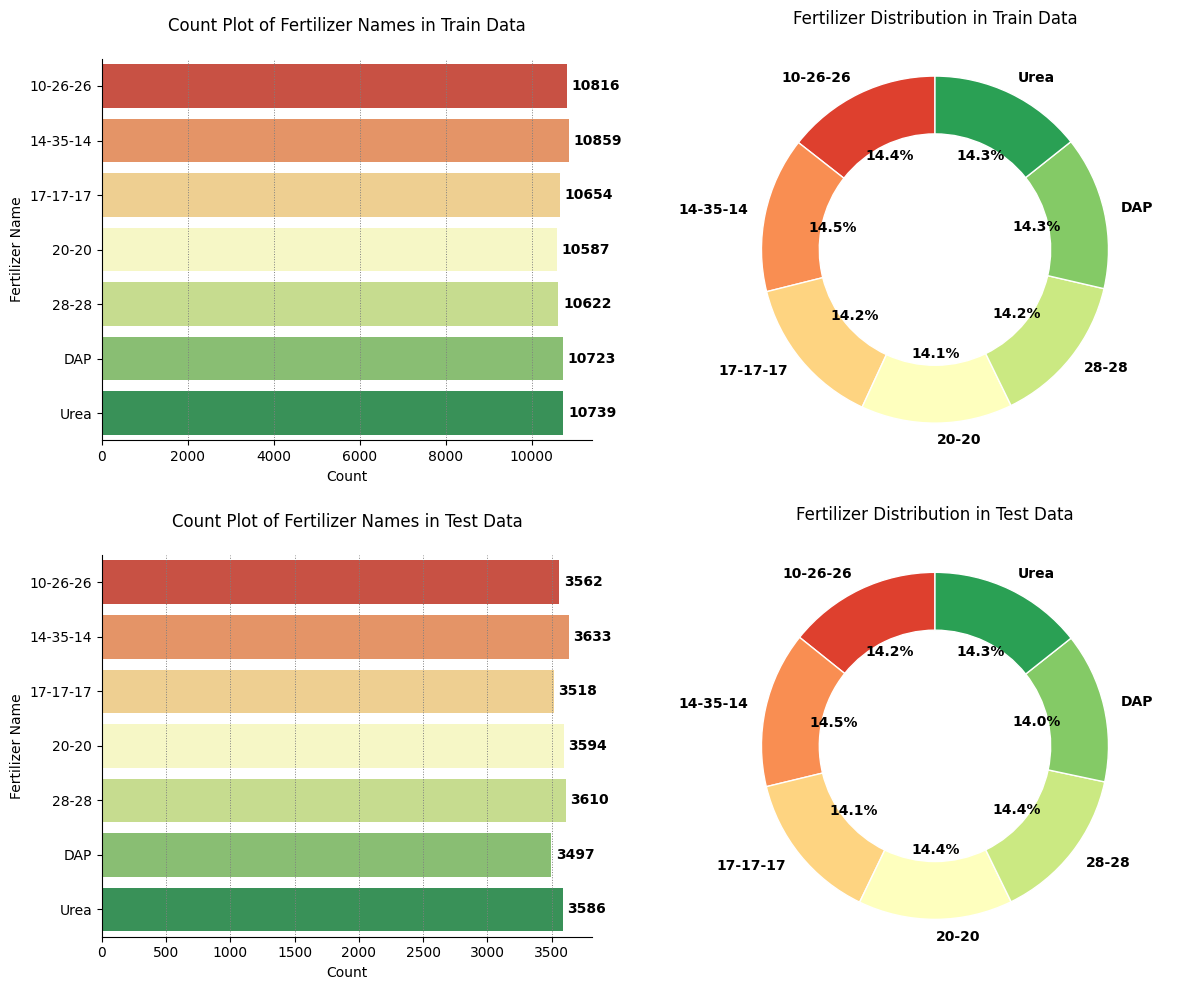

In [13]:
target_variable = 'Fertilizer Name'
all_categories = pd.concat([train_data[target_variable], test_data[target_variable]]).unique()
sorted_categories = sorted(all_categories)
custom_palette = dict(zip(sorted_categories, sns.color_palette("RdYlGn", len(sorted_categories))))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
datasets = [('Train Data', train_data), ('Test Data', test_data)]

for i, (title, data) in enumerate(datasets):
    ax = axes[i, 0]
    
    sns.countplot(
        y=target_variable,
        data=data,
        ax=ax,
        hue=target_variable,
        palette=custom_palette,
        legend=False,
        order=sorted_categories
    )
    ax.set_title(f'Count Plot of Fertilizer Names in {title}', pad=20)
    ax.set_ylabel('Fertilizer Name')
    ax.set_xlabel('Count')
    ax.grid(axis='x', color='gray', linestyle=':', linewidth=0.7)
    
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
    
    for p in ax.patches:
        width = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.text(width + max(data[target_variable].value_counts()) * 0.01,
                y,
                f'{int(width)}',
                ha='left', va='center', fontsize=10, fontweight='bold', color='black')

    fertilizer_counts = data[target_variable].value_counts().reindex(sorted_categories, fill_value=0)
    wedges, texts, autotexts = axes[i, 1].pie(
        fertilizer_counts,
        labels=fertilizer_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=[custom_palette[cat] for cat in fertilizer_counts.index],
        wedgeprops=dict(width=0.4, edgecolor='w'),
        radius=1.2
    )
    
    for text in texts + autotexts:
        text.set_fontsize(10)
        text.set_fontweight('bold')
    
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    axes[i, 1].add_artist(centre_circle)
    axes[i, 1].set_title(f'Fertilizer Distribution in {title}', pad=25)
    axes[i, 1].axis('equal')

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()

### Insights into Fertilizer Name Distribution¶

**Frequency of Fertilizer Names**

The count plots reveal the absolute counts of each fertilizer name in the dataset.

- Training Data:

    - 14-35-14 is the most frequent fertilizer, with 10,859 occurrences, accounting for approximately 14.5% of the dataset.
    - 10-26-26 is also highly prevalent, with 10,816 counts (~14.4%).
    - 20-20 has the lowest count at 10,587, representing 14.1% of the dataset.

- Testing Data:
    
    - Similar to the training data, 14-35-14 is most common with 3633 instances (~14.5%).
    - 28-28 is also highly prevalent, with 3610 counts (~14.4%).
    - DAP has the lowest count at 3497, representing 14% of the dataset.


Percentage Distribution

The donut charts provide a clear visualization of the percentage distribution of fertilizer names.
The percentage distribution is much more balanced in both the datasets, with each fertilizer type accounting for roughly 14% of the data. This might suggest better balance and diversity in both datasets.

## Numerical Feature Distributions

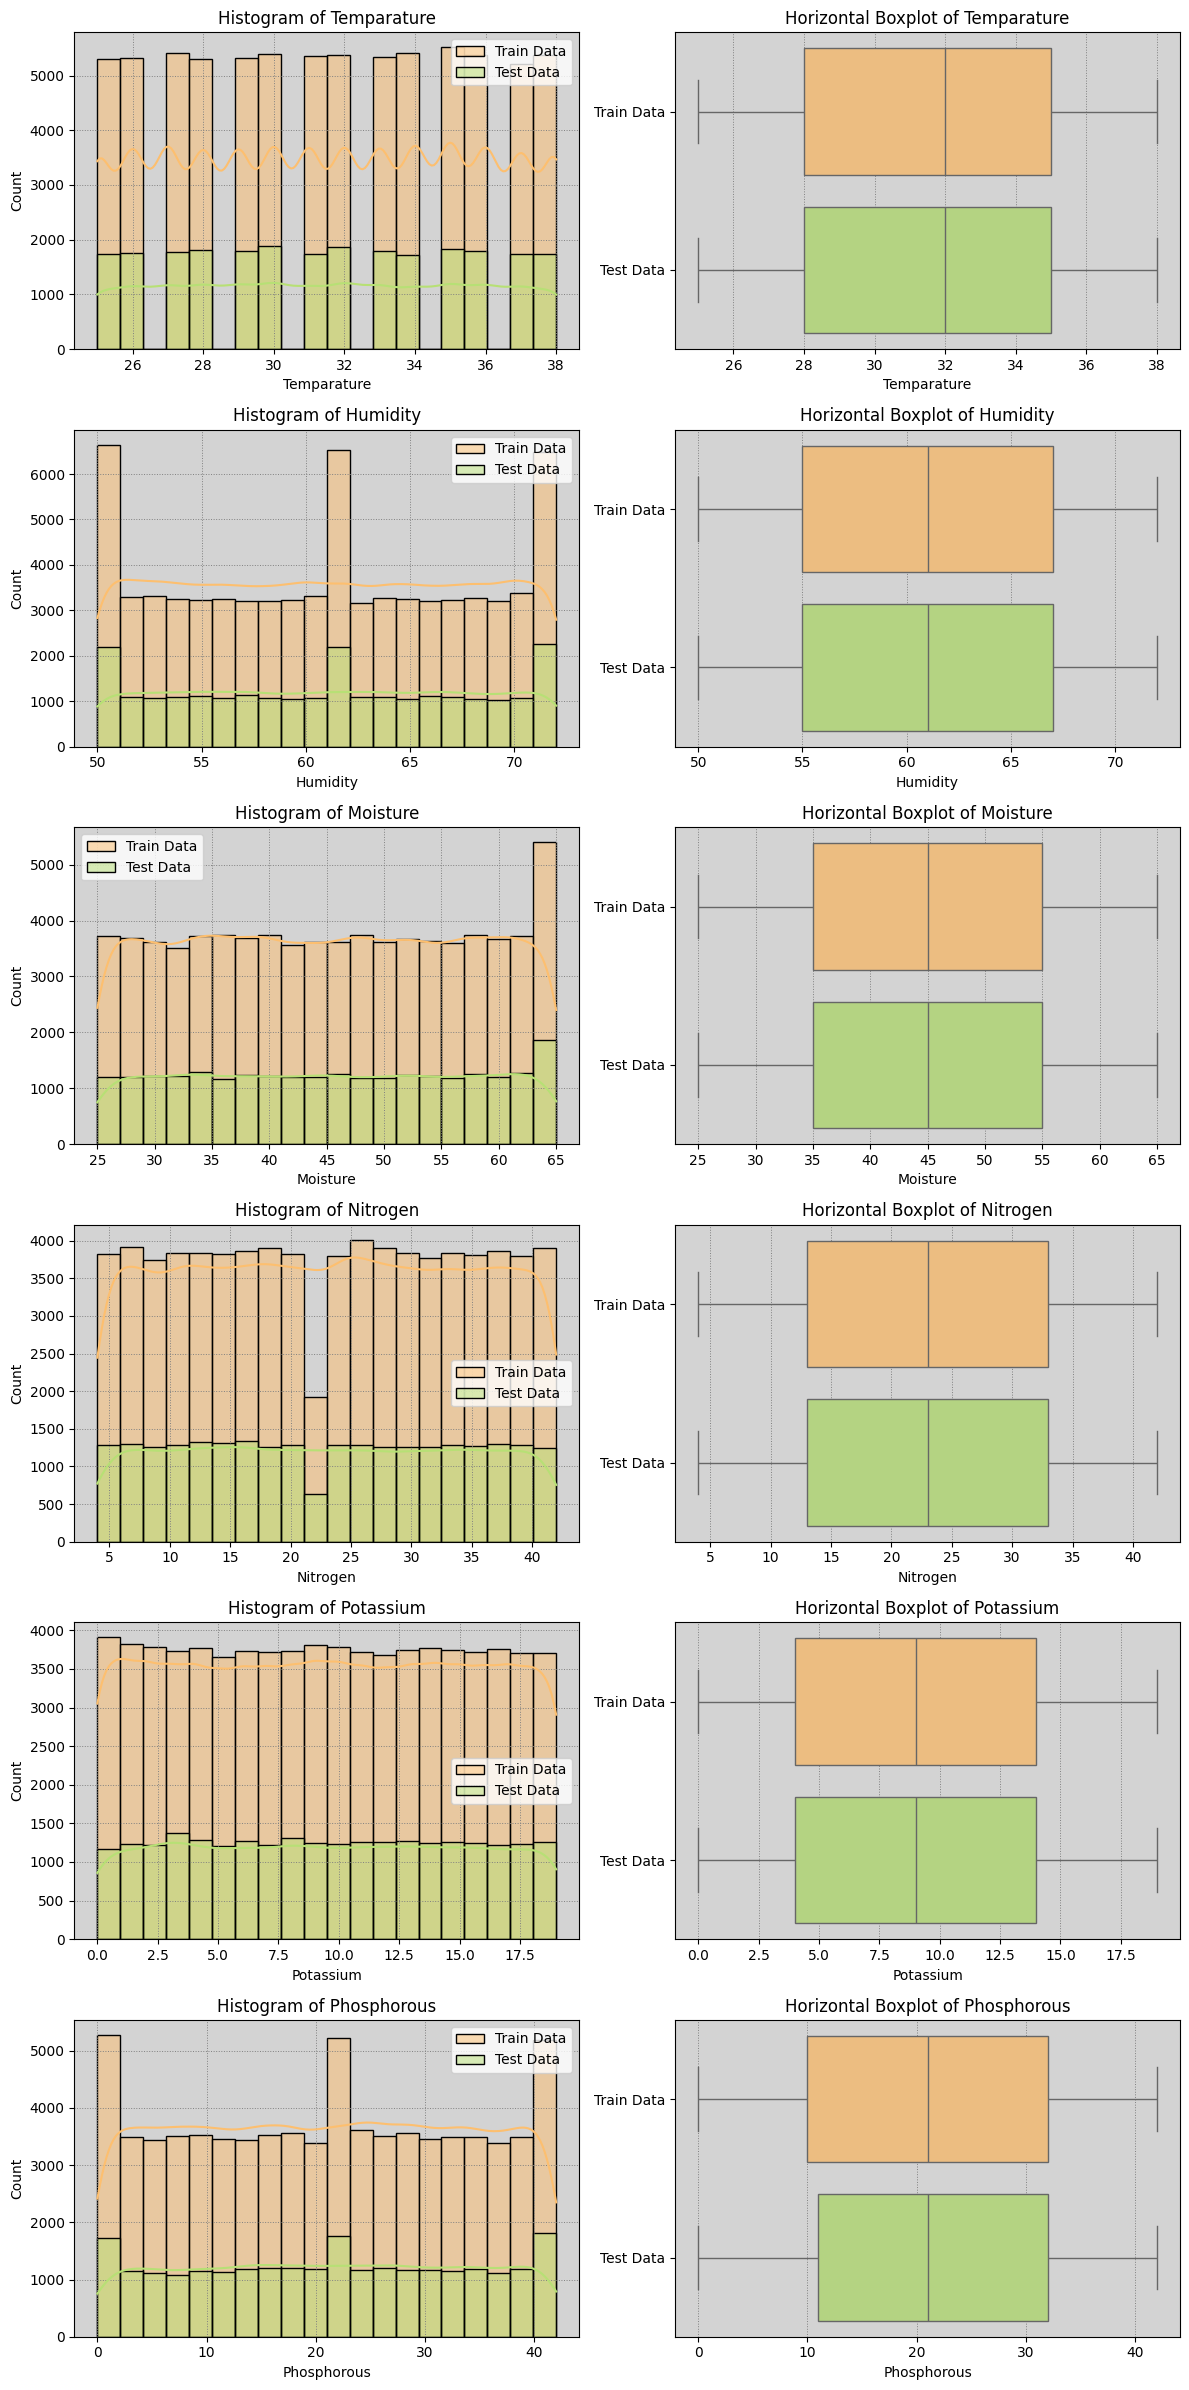

In [14]:
def plot_numerical_features_fixed(train_data, test_data, numerical_features):
    colors = sns.color_palette('RdYlGn', 2)
    fig, axes = plt.subplots(len(numerical_features), 2, figsize=(12, len(numerical_features)*4))
    axes = np.atleast_2d(axes)

    for i, feature in enumerate(numerical_features):
        sns.histplot(train_data[feature], color=colors[0], label='Train Data', bins=20, kde=True, ax=axes[i, 0])
        sns.histplot(test_data[feature], color=colors[1], label='Test Data', bins=20, kde=True, ax=axes[i, 0])
        axes[i, 0].set_title(f'Histogram of {feature}')
        axes[i, 0].legend()
        axes[i, 0].set_facecolor("lightgray")
        axes[i, 0].grid(color='gray', linestyle=':', linewidth=0.7)
        
        train_df_temp = pd.DataFrame({'value': train_data[feature], 'Dataset': 'Train Data'})
        test_df_temp = pd.DataFrame({'value': test_data[feature], 'Dataset': 'Test Data'})
        combined_df = pd.concat([train_df_temp, test_df_temp])
        sns.boxplot(data=combined_df, x='value', y='Dataset', hue='Dataset', palette=colors, orient='h', legend=False, ax=axes[i, 1])
        axes[i, 1].set_title(f'Horizontal Boxplot of {feature}')
        axes[i, 1].set_xlabel(feature)
        axes[i, 1].set_ylabel('') 
        axes[i, 1].set_facecolor("lightgray")
        axes[i, 1].grid(axis='x', color='gray', linestyle=':', linewidth=0.7)
    
    plt.tight_layout()
    plt.show()

numerical_features = ['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']
plot_numerical_features_fixed(train_data, test_data, numerical_features)

In [15]:
def check_skewness(data, dataset_name, highlight=True, sort=True):
    skewness_dict = {}
    for feature in data.select_dtypes(include=[np.number]).columns:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient='index', columns=['Skewness'])
    if sort:
        skew_df = skew_df.reindex(skew_df['Skewness'].abs().sort_values(ascending=False).index)
    
    print(f"\n Skewness for {dataset_name}:")
    print("-"*55)
    print(f"{'Feature':<18} | {'Skewness':<10} | {'Remark'}")
    print("-"*55)
    for feature, row in skew_df.iterrows():
        skew = row['Skewness']
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            color = '\033[91m'  
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
            color = '\033[93m'  
        else:
            remark = "Approximately symmetric"
            color = ''
        endc = '\033[0m' if color else ''
        if highlight and color:
            print(f"{color}{feature:<18} | {skew:>+9.4f} | {remark}{endc}")
        else:
            print(f"{feature:<18} | {skew:>+9.4f} | {remark}")
    print("-"*55)
    return skew_df

skew_train = check_skewness(train_data, "Train Data")
skew_test = check_skewness(test_data, "Test Data")


 Skewness for Train Data:
-------------------------------------------------------
Feature            | Skewness   | Remark
-------------------------------------------------------
Temparature        |   -0.0040 | Approximately symmetric
Humidity           |   +0.0026 | Approximately symmetric
Potassium          |   +0.0023 | Approximately symmetric
Moisture           |   +0.0012 | Approximately symmetric
Phosphorous        |   -0.0007 | Approximately symmetric
Nitrogen           |   +0.0003 | Approximately symmetric
-------------------------------------------------------

 Skewness for Test Data:
-------------------------------------------------------
Feature            | Skewness   | Remark
-------------------------------------------------------
Phosphorous        |   -0.0116 | Approximately symmetric
Nitrogen           |   +0.0106 | Approximately symmetric
Potassium          |   +0.0071 | Approximately symmetric
Temparature        |   +0.0038 | Approximately symmetric
Humidity       

### Insights on Numerical Feature Distributions

**Distribution Consistency Across Datasets**

Histograms and boxplots for all numerical features (Temparature, Humidity, Moisture, Nitrogen, Potassium, Phosphorous) show that both the datasets have nearly identical distributions.

Shape and Spread of Distributions

Histograms reveal that all features are distributed fairly evenly across their respective ranges, with no significant outliers or heavy tails.
Boxplots confirm that the central 50% of values (the interquartile range) is similarly placed for all datasets, and the whiskers (showing the range) are nearly identical, further supporting the conclusion of consistent data generation.

**Skewness Analysis**

The skewness values for all numerical features in both the datasets are extremely close to zero, indicating that the distributions are approximately symmetric.
No feature exhibits moderate or high skewness (|skewness| > 0.5), which means:
There is no need for transformations like log or Box-Cox to normalize these features.
Most machine learning algorithms will be able to handle these features without bias due to skewed distributions.

**Feature-Specific Observations**

Temperature, Humidity, and Moisture:
These environmental features are well-distributed, with no evidence of clustering or gaps in the data.
Nitrogen, Potassium, Phosphorous:
Soil nutrient levels also show a uniform spread, ensuring that the model can learn from a wide variety of soil conditions.


## Correlation Analysis of Numerical Features

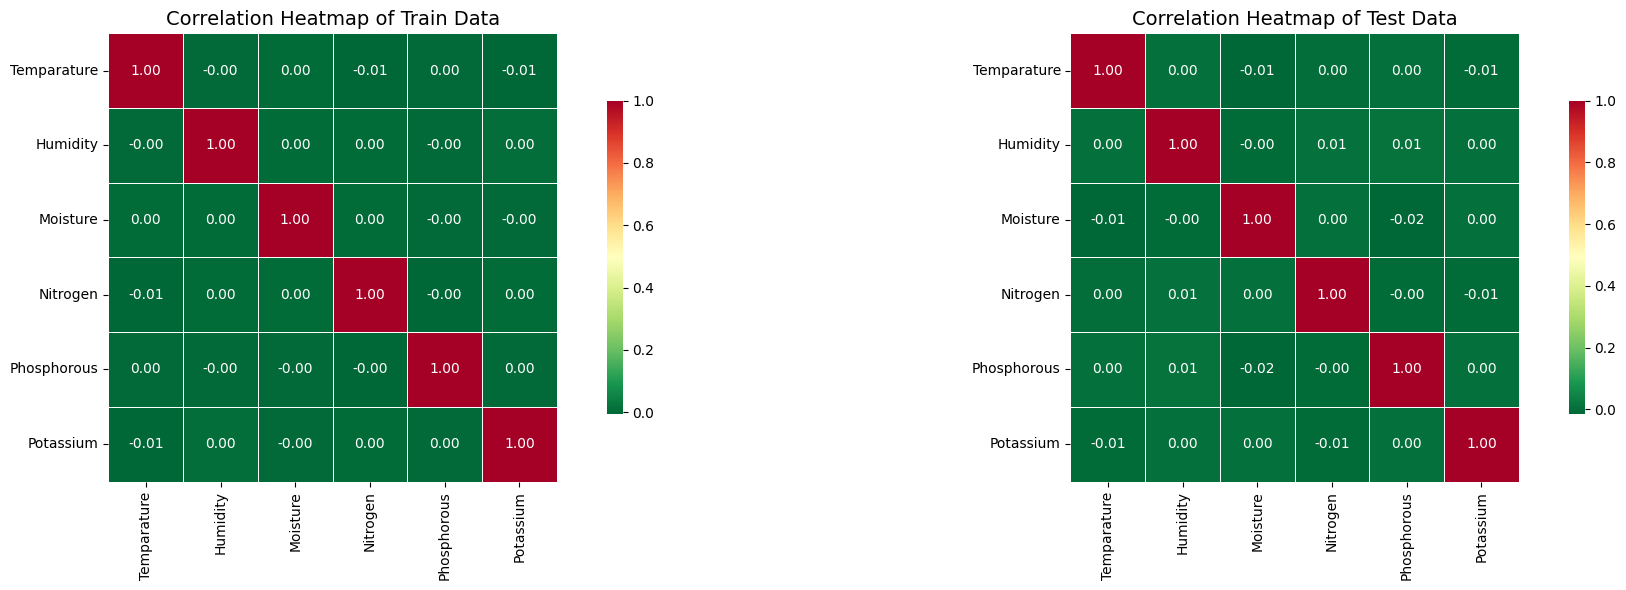

In [16]:
numerical_features = ['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Phosphorous', 'Potassium']

datasets = {
    "Train Data": train_data,
    "Test Data": test_data
}

fig, axes = plt.subplots(ncols=2, figsize=(20, 6))  
axs = axes.ravel() 

for i, (name, df) in enumerate(datasets.items()):
    available_features = [f for f in numerical_features if f in df.columns]
    df_subset = df[available_features]
    
    corr = df_subset.corr()
    
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn_r",   
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": .7},
        ax=axs[i]
    )
    axs[i].set_title(f'Correlation Heatmap of {name}', fontsize=14)

plt.tight_layout()
plt.show()

### Insights from Correlation Analysis of Numerical Features¶

**Overall Weak Correlations**

The correlation matrices for bith the datasets consistently show very weak correlations among the numerical features.
Most correlation coefficients are close to zero, indicating little to no linear relationship between pairs of features such as Temperature, Humidity, Moisture, Nitrogen, Phosphorous, and Potassium.

**Feature Independence**

Features like Temperature, Humidity, and Moisture are essentially uncorrelated with each other and with soil nutrient levels (Nitrogen, Phosphorous, Potassium).
Similarly, the soil nutrients themselves show near-zero correlations, suggesting that their levels vary independently within the dataset.

**Implications for Modeling**

The near-zero correlations imply that each numerical feature provides unique, non-redundant information for predicting the optimal fertilizer.
This independence is beneficial because it reduces multicollinearity issues in models, allowing algorithms to learn the distinct impact of each feature without confounding effects.
However, the lack of strong linear relationships suggests that complex or non-linear models (e.g., tree-based methods, neural networks) might better capture interactions or subtle patterns that linear correlation does not reveal.

## Categorical Feature Distributions

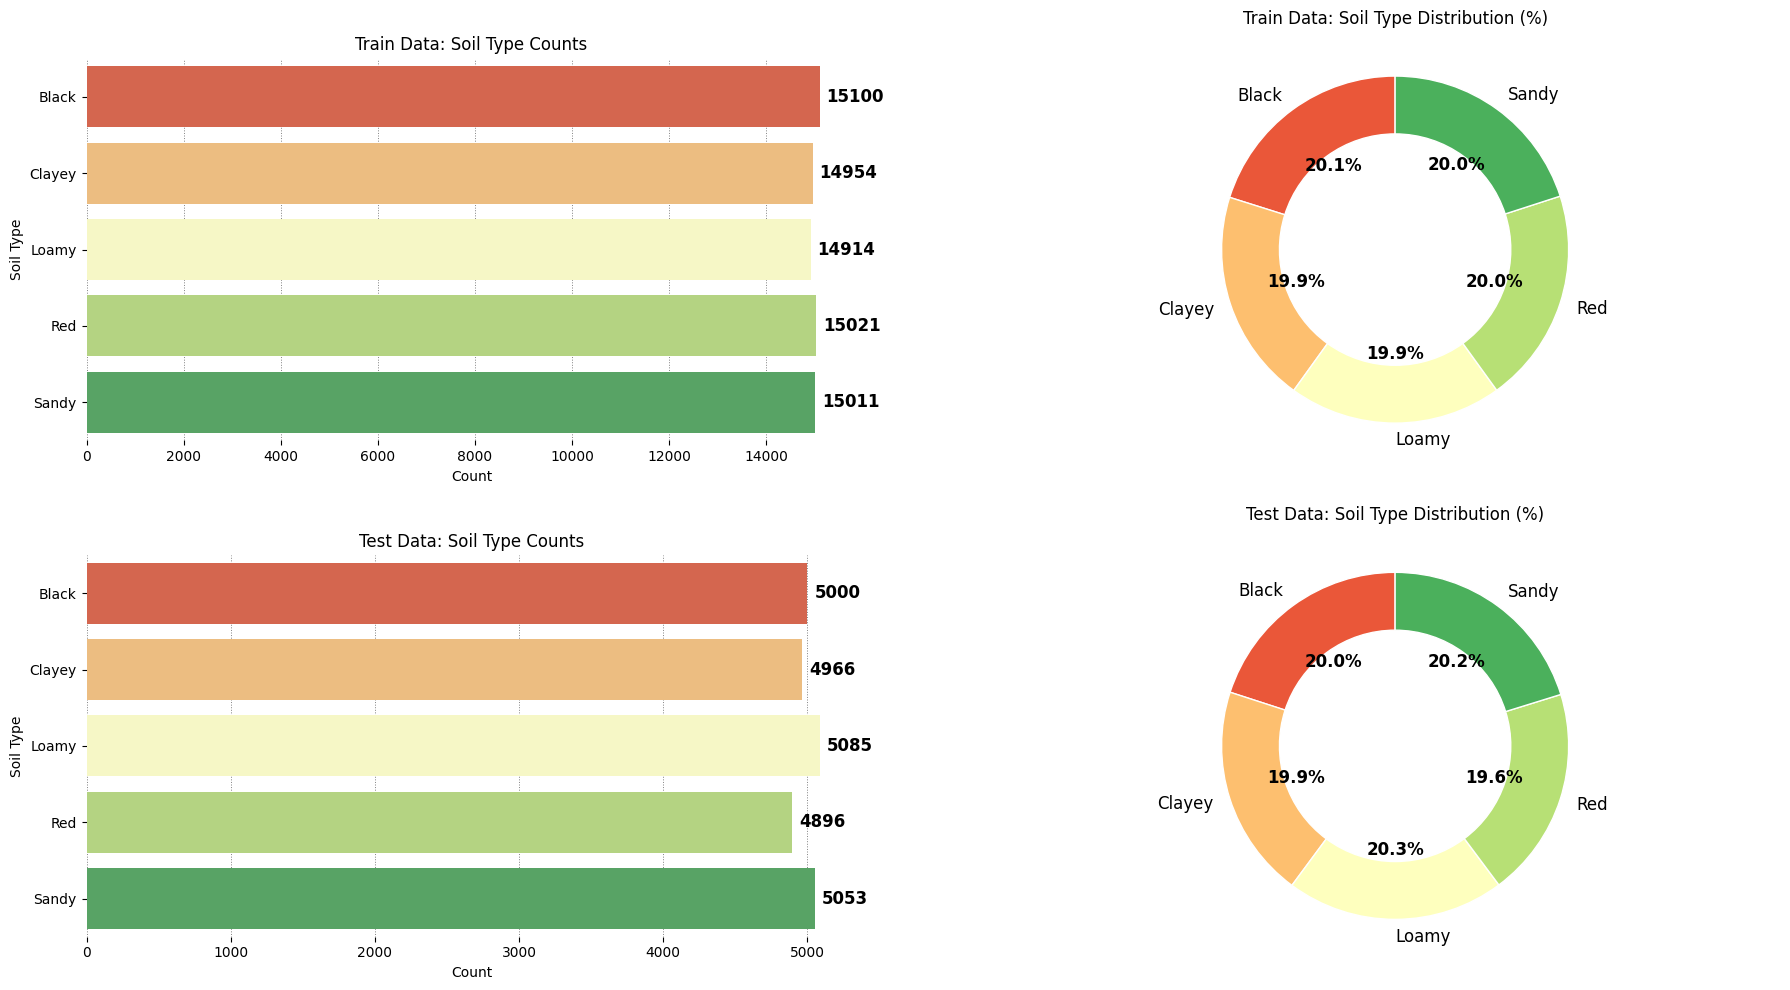

In [17]:
def plot_categorical_distribution_across_datasets(train_data, test_data, feature):
    all_categories = pd.concat([train_data[feature], test_data[feature]]).dropna().unique()
    sorted_categories = sorted(all_categories)

    palette_colors = sns.color_palette("RdYlGn", n_colors=len(sorted_categories))
    custom_palette = dict(zip(sorted_categories, palette_colors))

    dataset_pairs = [('Train Data', train_data), ('Test Data', test_data)]

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))

    for i, (name, data) in enumerate(dataset_pairs):
        ax_bar = axes[i, 0]
        
        sns.countplot(
            y=feature,
            data=data,
            ax=ax_bar,
            hue=feature,
            palette=custom_palette,
            order=sorted_categories,
            legend=False
        )
        
        ax_bar.set_title(f'{name}: {feature} Counts')
        ax_bar.set_xlabel('Count')
        ax_bar.set_ylabel(feature)
        
        for p in ax_bar.patches:
            width = p.get_width()
            if width > 0:
                y = p.get_y() + p.get_height() / 2
                ax_bar.annotate(f'{int(width)}',
                                xy=(width, y),
                                xytext=(5, 0),
                                textcoords='offset points',
                                ha='left', va='center',
                                fontsize=12, color='black', fontweight='bold')

        ax_bar.set_axisbelow(True)
        ax_bar.grid(axis='x', color='gray', linestyle=':', linewidth=0.7)
        sns.despine(left=True, bottom=True, ax=ax_bar)

        ax_pie = axes[i, 1]
        counts = data[feature].value_counts().reindex(sorted_categories, fill_value=0)
        non_zero_counts = counts[counts > 0]
        
        if len(non_zero_counts) > 0:
            labels = non_zero_counts.index
            sizes = non_zero_counts.values
            colors = [custom_palette[label] for label in labels]

            wedges, texts, autotexts = ax_pie.pie(
                sizes,
                labels=labels,
                autopct='%1.1f%%',
                startangle=90,
                colors=colors,
                textprops={'fontsize': 12},
                wedgeprops=dict(width=0.4, edgecolor='w'),
                radius=1.2
            )

            for autotext in autotexts:
                autotext.set_color('black')
                autotext.set_fontweight('bold')

            centre_circle = Circle((0, 0), 0.70, fc='white')
            ax_pie.add_artist(centre_circle)

        ax_pie.set_title(f'{name}: {feature} Distribution (%)', pad=25)

    for i in range(2):
        axes[i, 1].axis('equal')

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3, wspace=0.2)
    plt.show()

plot_categorical_distribution_across_datasets(train_data, test_data, 'Soil Type')

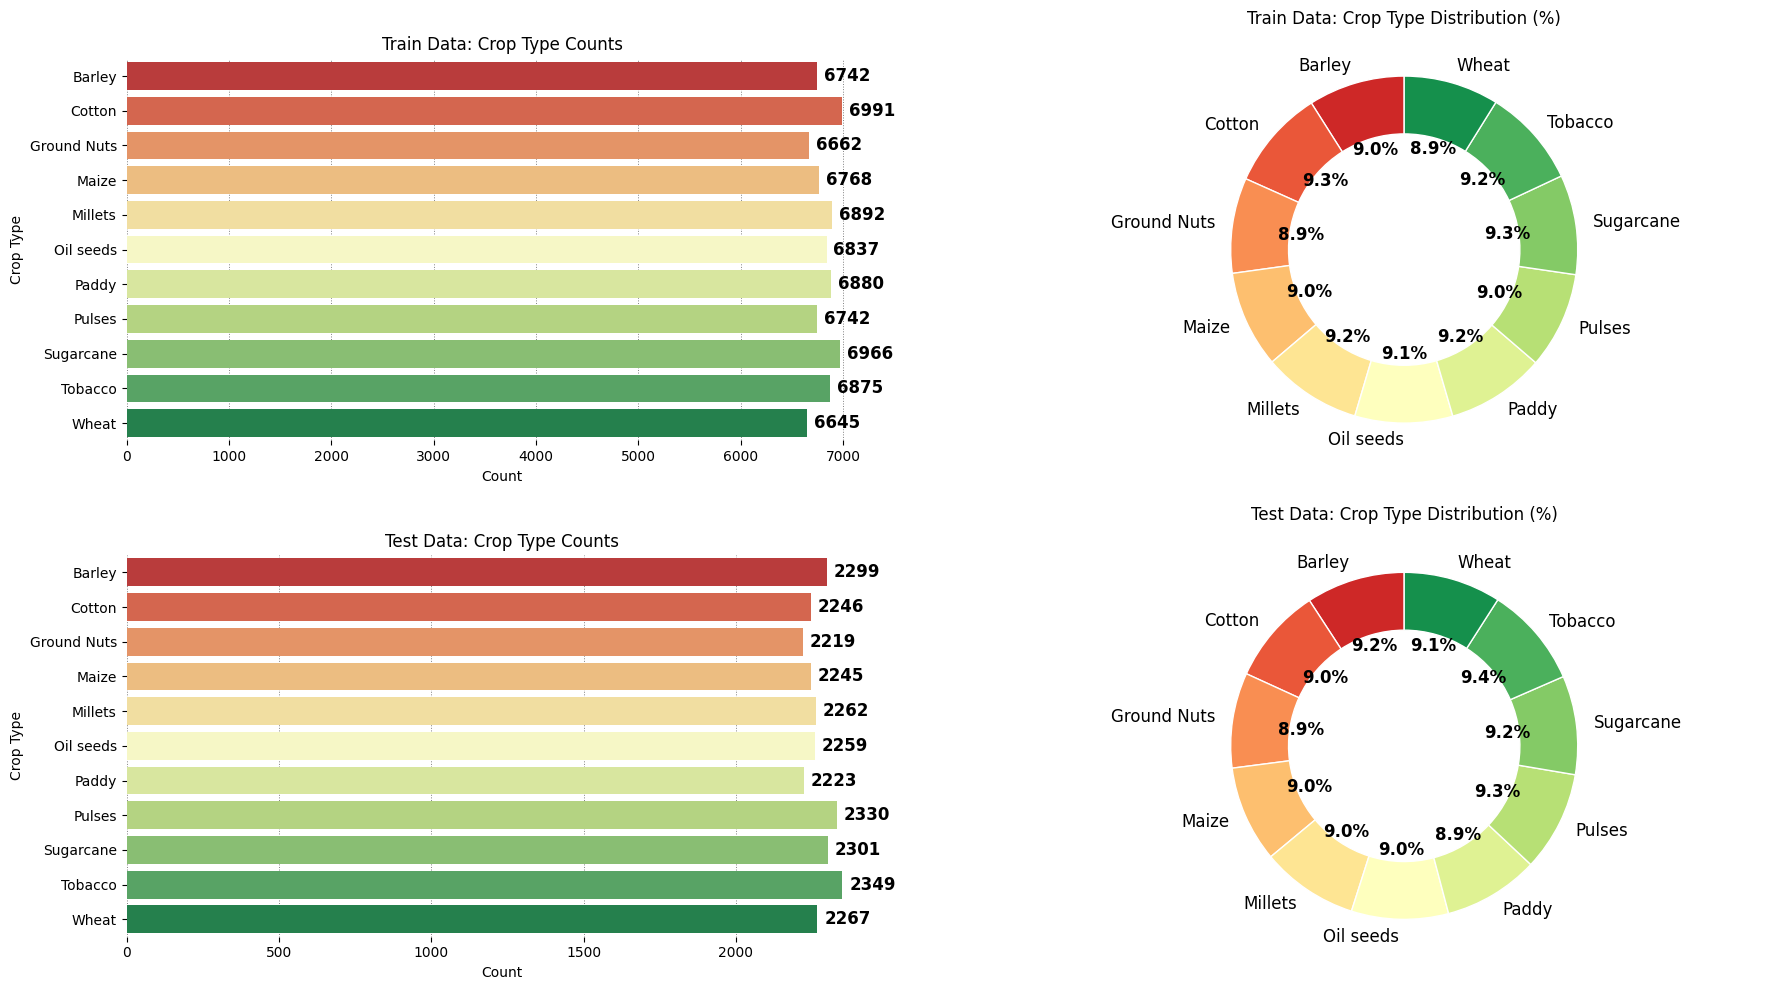

In [18]:
plot_categorical_distribution_across_datasets(train_data, test_data, 'Crop Type')

## Insights on Soil Type and Crop Type Distributions

### Soil Type Distribution

- The dataset contains five distinct soil types: **Sandy, Black, Clayey, Red, and Loamy**.
- Across both the datasets, the distribution of these soil types is remarkably balanced, with each type representing roughly **19–21%** of the samples.
- For example, in the training data, **Sandy** soil accounts for about **20%**, and **Black** soil about **20.1%**, with other types closely following.
- This balanced representation ensures that the model will learn fertilizer recommendations across diverse soil conditions, improving its generalization.

> *Different soil types have unique physical and chemical properties that affect water retention, nutrient availability, and crop suitability.*

---

### Crop Type Distribution

- The dataset includes **11 crop types**, such as **Paddy, Pulses, Cotton, Tobacco, Wheat, Millets, Barley, Sugarcane, Oil seeds, Maize, and Ground Nuts**.
- The crop distribution is fairly uniform, with no single crop dominating the dataset. 
- This diversity in crop types allows the model to learn fertilizer recommendations tailored to a wide variety of crops, which is critical since nutrient needs vary significantly by crop species.

> *Crop suitability depends heavily on soil type and nutrient availability. For example, Paddy thrives in water-retentive soils like clay or loam, while Millets and Barley are better suited for lighter, sandy soils.*

> *Understanding the interaction between crop type and soil characteristics is essential for precision fertilizer recommendations that optimize yield and sustainability.*

---

### Feature Grouping for Fertilizer Prediction

| **Group**                  | **Features**                             | **Rationale / Focus**                                                                                                                                 |
|---------------------------|------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Climatic / Environmental** | Temperature, Humidity, Soil Moisture     | Capture environmental conditions influencing crop growth and fertilizer needs. Soil moisture is dynamic and influenced by weather and irrigation.    |
| **Soil Characteristics**     | Soil Type                                | Reflects physical and chemical soil properties that affect nutrient retention and fertilizer effectiveness. Static and distinct from environment.   |
| **Crop Information**         | Crop Type                                | Different crops have varying nutrient requirements and fertilizer responses. Helps tailor recommendations.                                           |
| **Soil Nutrients**           | Nitrogen (N), Phosphorus (P), Potassium (K) | Core macronutrients critical for plant growth. Their levels directly impact fertilizer choice and dosage.                                            |

---

### Explanation and Justification

- **Environmental Group:**
  - Temperature, humidity, and soil moisture collectively represent the dynamic environmental context affecting nutrient uptake and fertilizer efficiency.
  - Soil moisture is included because it fluctuates with weather and irrigation, influencing nutrient availability and crop stress.

- **Soil Characteristics:**
  - Soil type influences water retention, aeration, and nutrient holding capacity.
  - It is a categorical feature capturing inherent soil properties, distinct from transient environmental variables.

- **Crop Information:**
  - Crop type affects fertilizer needs due to different nutrient uptake patterns and growth cycles.
  - Grouping it separately allows focused analysis on crop-specific fertilizer optimization.

- **Soil Nutrients:**
  - Nitrogen, phosphorus, and potassium are the primary macronutrients targeted by fertilizers.
  - Their measured levels provide direct signals for fertilizer recommendations.


In [19]:
env_features = ['Temparature', 'Humidity', 'Moisture']
soil_feature = 'Soil Type'
crop_feature = 'Crop Type'
nutrient_features = ['Nitrogen', 'Phosphorous', 'Potassium']

## Environmental Feature Levels by Fertilizer Classes

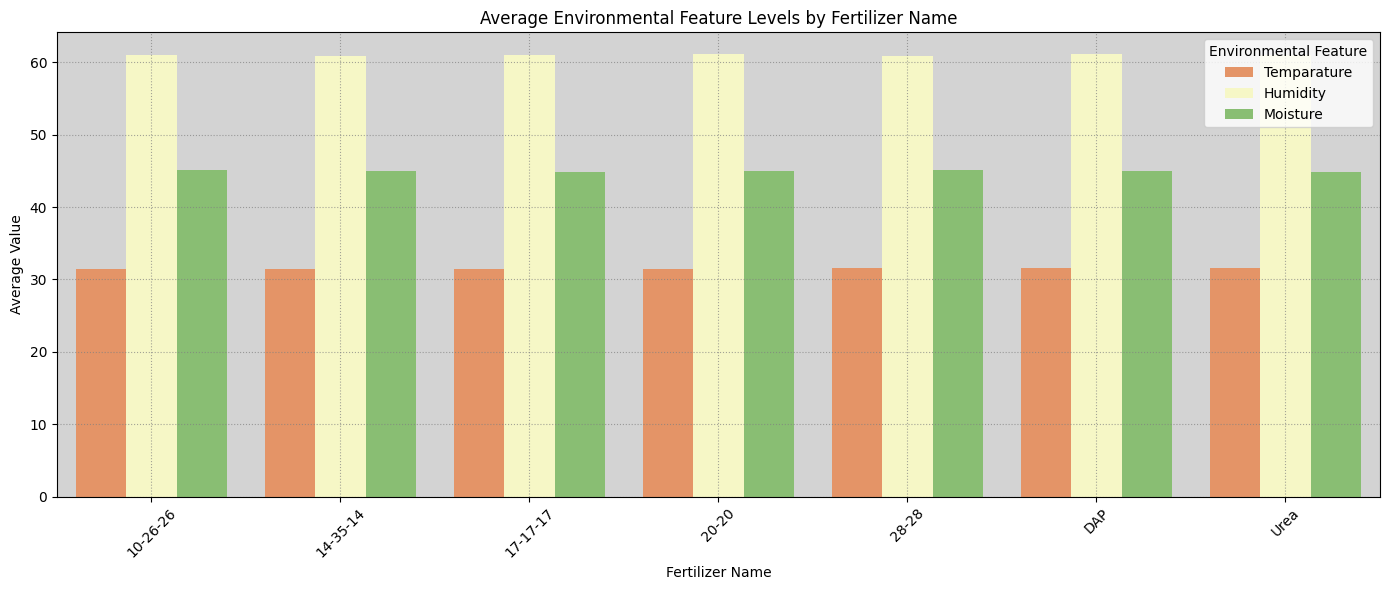

In [20]:
mean_env = train_data.groupby(target_variable)[env_features].mean().reset_index()
mean_env_melted = mean_env.melt(id_vars=target_variable, var_name='Environmental Feature', value_name='Mean Value')

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=mean_env_melted, x=target_variable, y='Mean Value', hue='Environmental Feature', palette='RdYlGn', ax=ax)
ax.set_title(f'Average Environmental Feature Levels by {target_variable}')
ax.set_xlabel(target_variable)
ax.set_ylabel('Average Value')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Environmental Feature')
ax.set_facecolor('lightgray') 
ax.grid(color='gray', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [21]:
def env_summary_by_fertilizer(df, target_variable, env_features):
    print("=" * 65)
    print(f"Summary Statistics of Environmental Features by {target_variable}")
    print("=" * 65)
    
    for feature in env_features:
        summary_stats = df.groupby(target_variable)[feature].describe().round(2)
        print(f"\n--- {feature} ---\n")
        display(summary_stats)

env_summary_by_fertilizer(train_data, 'Fertilizer Name', env_features)

Summary Statistics of Environmental Features by Fertilizer Name

--- Temparature ---



,count,mean,std,min,25%,50%,75%,max
Fertilizer Name,,,,,,,,
10-26-26,10816.0,31.50,4.04,25.0,28.0,32.0,35.0,38.0
14-35-14,10859.0,31.50,4.01,25.0,28.0,32.0,35.0,38.0
17-17-17,10654.0,31.48,4.03,25.0,28.0,31.0,35.0,38.0
20-20,10587.0,31.47,4.04,25.0,28.0,31.0,35.0,38.0
28-28,10622.0,31.51,4.03,25.0,28.0,32.0,35.0,38.0
DAP,10723.0,31.53,4.02,25.0,28.0,32.0,35.0,38.0
Urea,10739.0,31.55,3.99,25.0,28.0,32.0,35.0,38.0



--- Humidity ---



,count,mean,std,min,25%,50%,75%,max
Fertilizer Name,,,,,,,,
10-26-26,10816.0,60.97,6.66,50.0,55.0,61.0,67.0,72.0
14-35-14,10859.0,60.90,6.62,50.0,55.0,61.0,67.0,72.0
17-17-17,10654.0,60.97,6.63,50.0,55.0,61.0,67.0,72.0
20-20,10587.0,61.08,6.65,50.0,55.0,61.0,67.0,72.0
28-28,10622.0,60.89,6.66,50.0,55.0,61.0,67.0,72.0
DAP,10723.0,61.08,6.70,50.0,55.0,61.0,67.0,72.0
Urea,10739.0,60.97,6.64,50.0,55.0,61.0,67.0,72.0



--- Moisture ---



,count,mean,std,min,25%,50%,75%,max
Fertilizer Name,,,,,,,,
10-26-26,10816.0,45.05,11.83,25.0,35.0,45.0,55.0,65.0
14-35-14,10859.0,44.96,11.81,25.0,35.0,45.0,55.0,65.0
17-17-17,10654.0,44.85,11.76,25.0,35.0,45.0,55.0,65.0
20-20,10587.0,45.00,11.84,25.0,35.0,45.0,55.0,65.0
28-28,10622.0,45.18,11.89,25.0,35.0,45.0,56.0,65.0
DAP,10723.0,44.97,11.93,25.0,34.0,45.0,55.0,65.0
Urea,10739.0,44.89,11.80,25.0,35.0,45.0,55.0,65.0


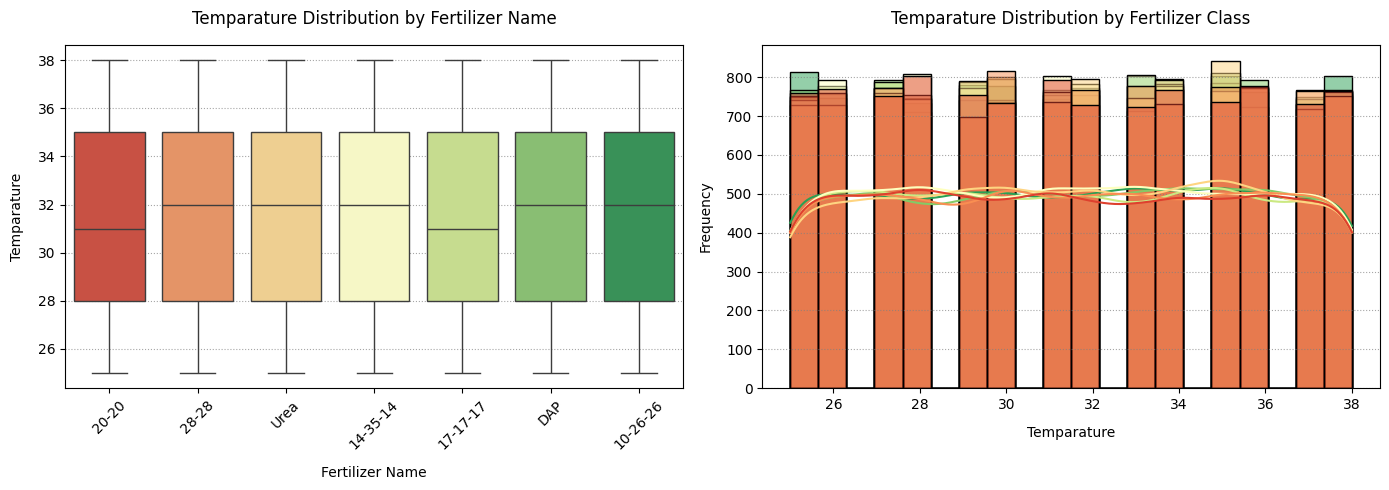

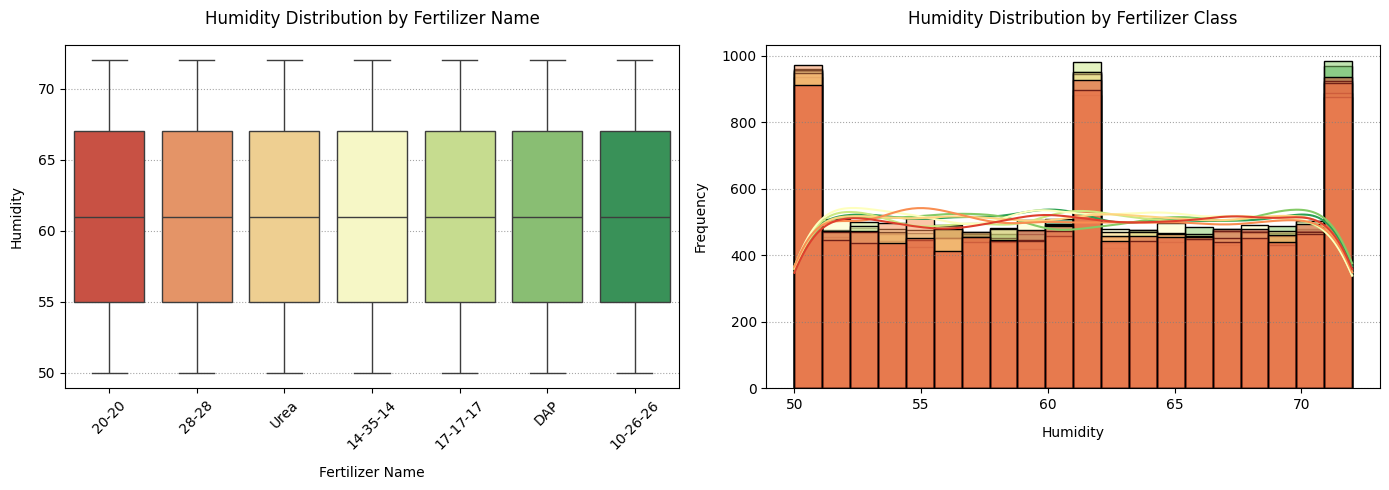

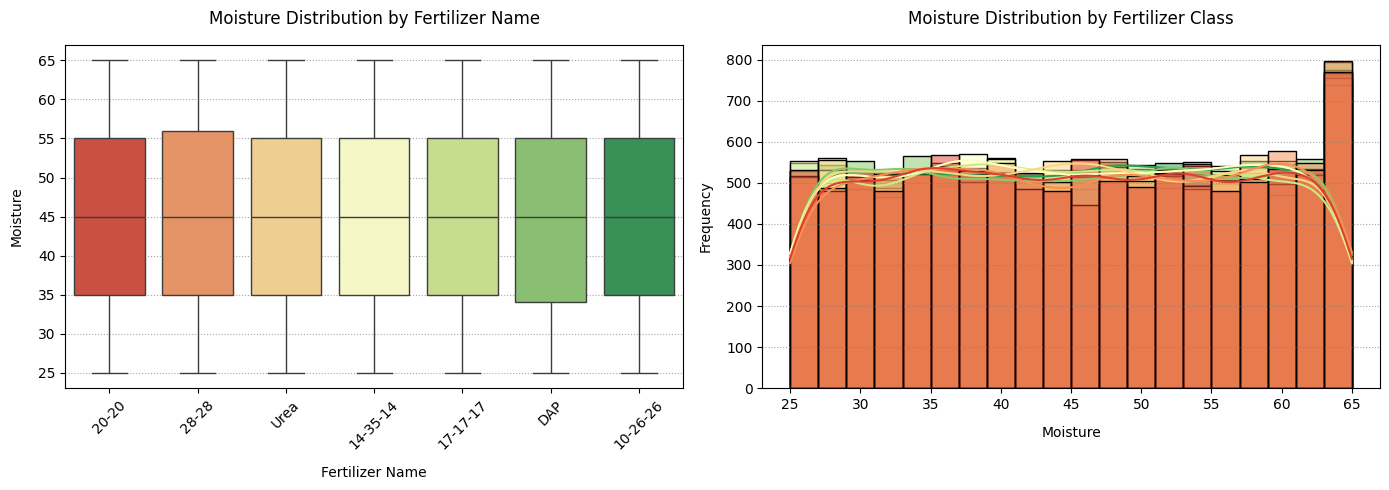

In [22]:
custom_palette = sns.color_palette("RdYlGn", len(train_data[target_variable].unique()))

for feature in env_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxplot(x=target_variable, y=feature, data=train_data,
                hue=target_variable, palette=custom_palette, ax=axes[0], legend=False)
    axes[0].set_title(f'{feature} Distribution by Fertilizer Name', pad=15)
    axes[0].set_xlabel('Fertilizer Name', labelpad=10)
    axes[0].set_ylabel(feature, labelpad=10)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', color='gray', linestyle=':', alpha=0.7)
    
    # Histogram remains unchanged
    sns.histplot(data=train_data, x=feature, hue=target_variable,
                 bins=20, palette=custom_palette, ax=axes[1], kde=True, legend=False)
    axes[1].set_title(f'{feature} Distribution by Fertilizer Class', pad=15)
    axes[1].set_xlabel(feature, labelpad=10)
    axes[1].set_ylabel('Frequency', labelpad=10)
    axes[1].grid(axis='y', color='gray', linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

### Insights on Environmental Feature Levels by Fertilizer Type

**Overview of Environmental Conditions Across Fertilizers**

The average levels of key environmental features—Temperature, Humidity, and Soil Moisture—were analyzed for each fertilizer type in the training dataset.
The barplot visualization shows that these environmental variables have very similar mean values across all fertilizer classes, indicating that fertilizers are applied under broadly comparable environmental conditions.

**Detailed Summary Statistics**

The summary statistics confirm that for Temperature, the mean values for all fertilizer types hover around 31.5°C, with minimum and maximum values spanning from 25°C to 38°C.
Humidity averages range narrowly between approximately 60.9% and 61.08%, with a consistent spread across fertilizers.
Soil Moisture shows slightly more variation, with mean values between 44.89 and 45.18, but overall the distributions are quite close.
The standard deviations and quartiles for these features are also similar across fertilizer types, suggesting uniform environmental conditions during fertilizer application.

**Distribution Patterns**

The boxplots and histograms further illustrate that the distributions of temperature, humidity, and moisture overlap substantially among fertilizer classes.
This implies that environmental factors alone do not strongly differentiate fertilizer usage in this dataset, and other factors such as soil nutrients and crop type likely play a more decisive role in fertilizer selection.

## Soil Type Distribution Across Fertilizer Classes

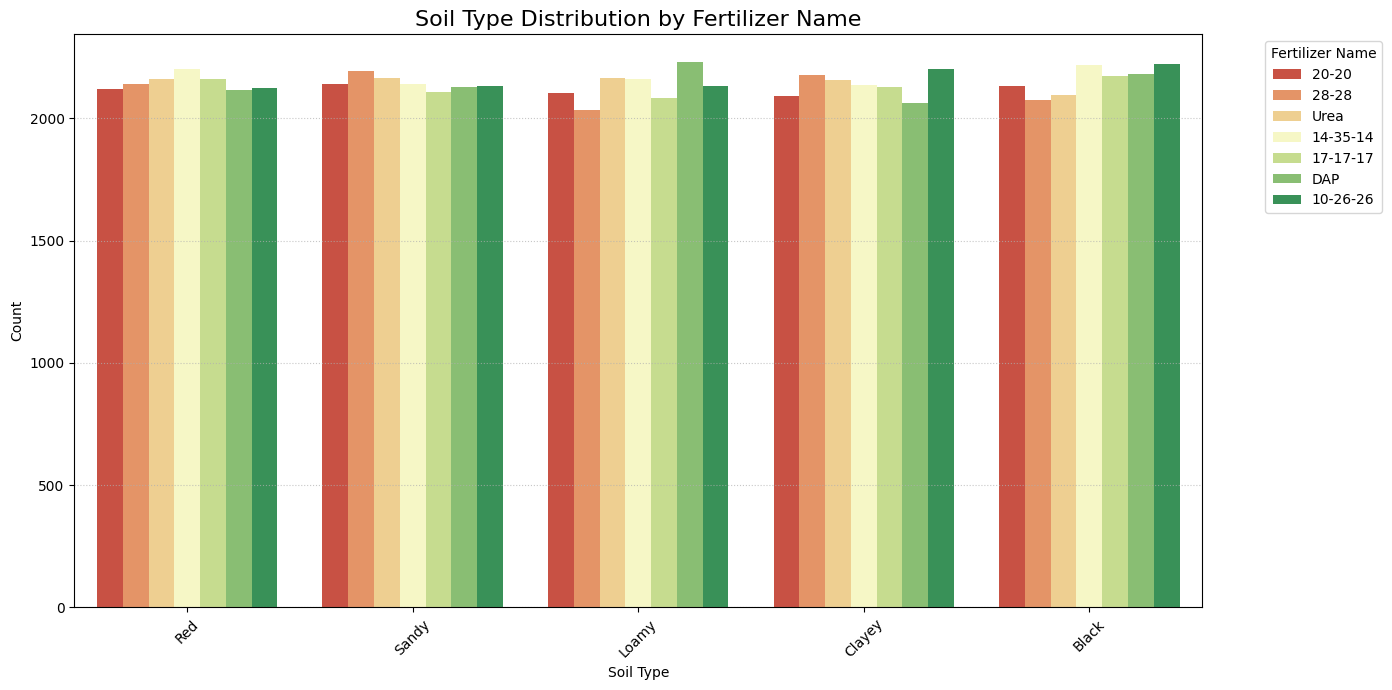

In [23]:
custom_palette = sns.color_palette("RdYlGn", n_colors=train_data[target_variable].nunique())

def plot_categorical_vs_target(data, category_feature, target_feature, palette):
    plt.figure(figsize=(14, 7))
    ax = sns.countplot(x=category_feature, hue=target_feature, data=data, palette=palette)
    plt.title(f'{category_feature} Distribution by {target_feature}', fontsize=16)
    plt.xlabel(category_feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    
    plt.legend(title=target_feature, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_categorical_vs_target(train_data, soil_feature, target_variable, custom_palette)

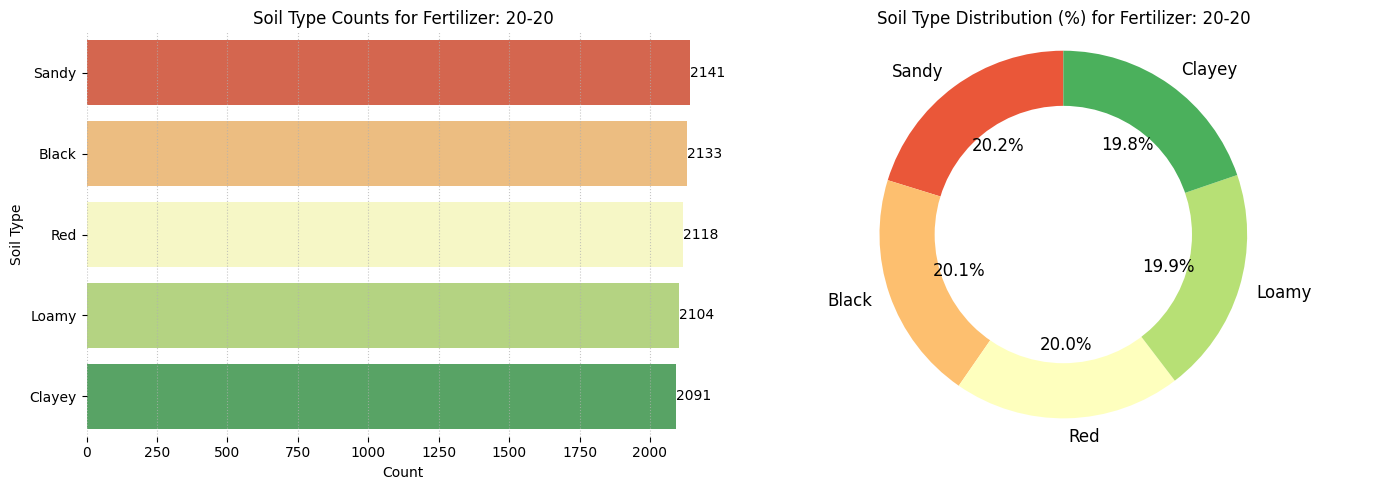

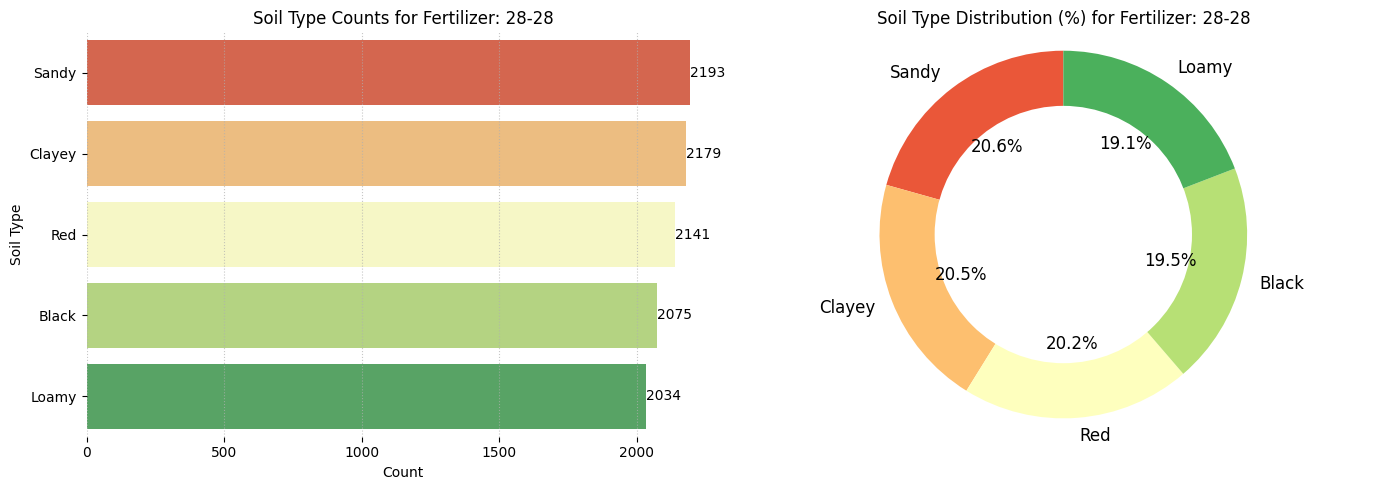

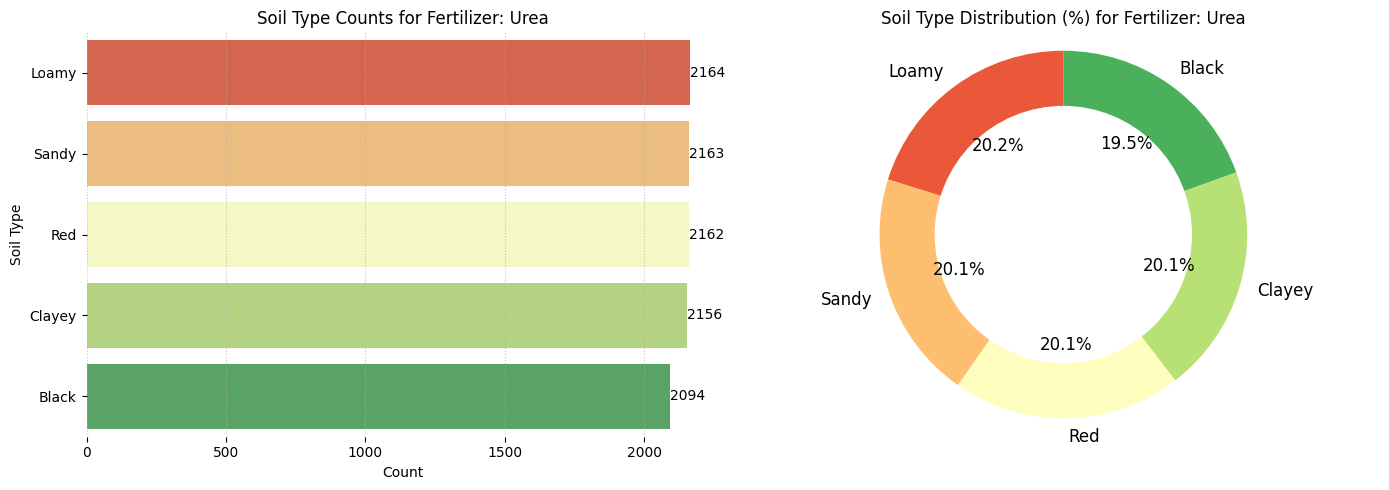

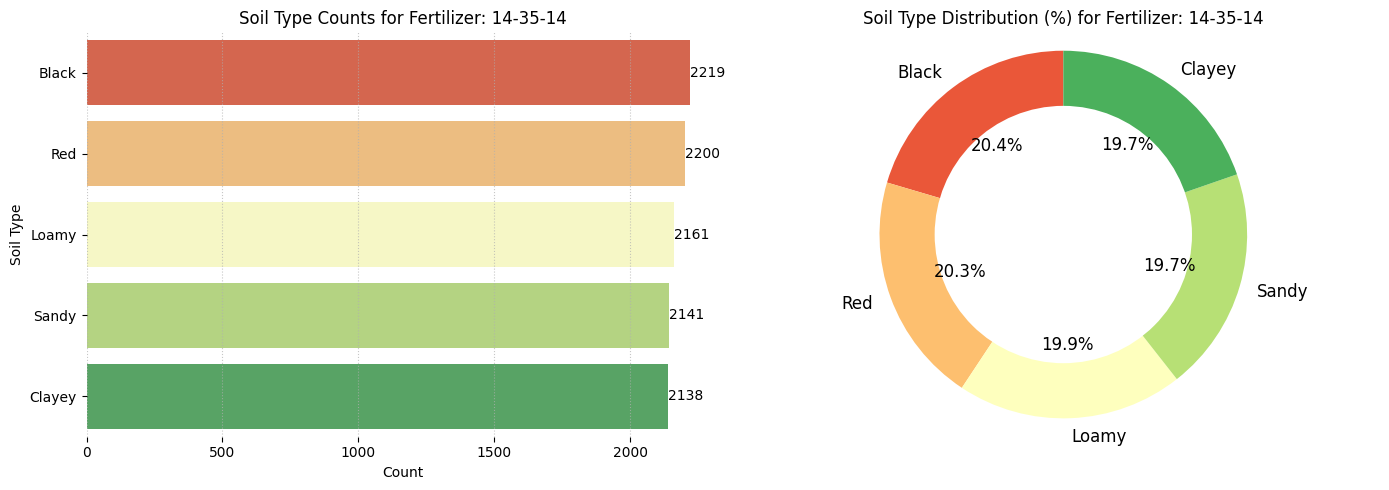

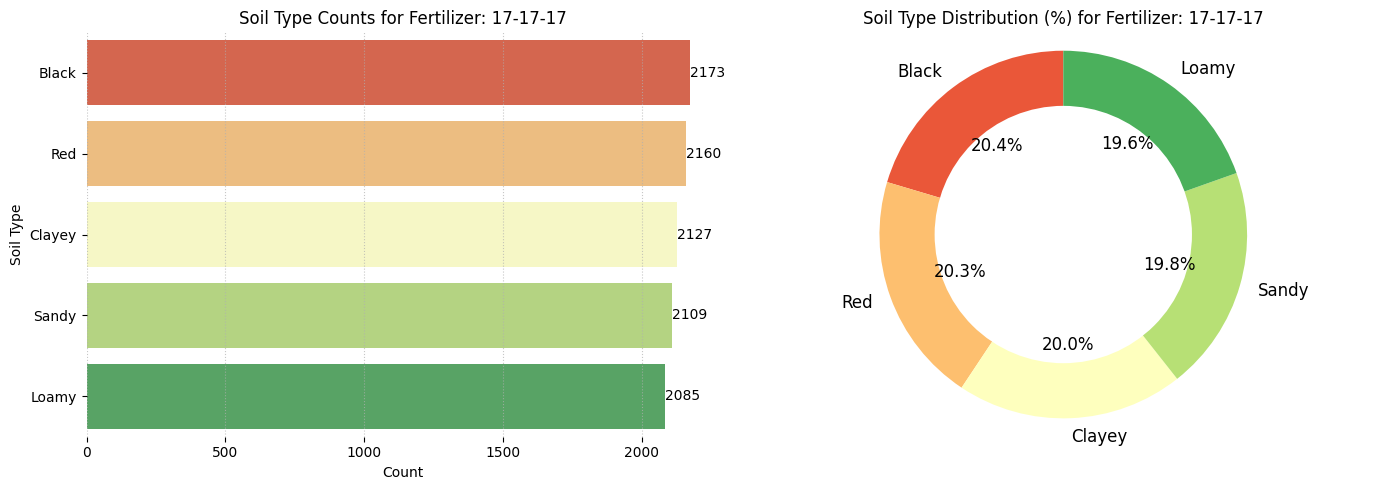

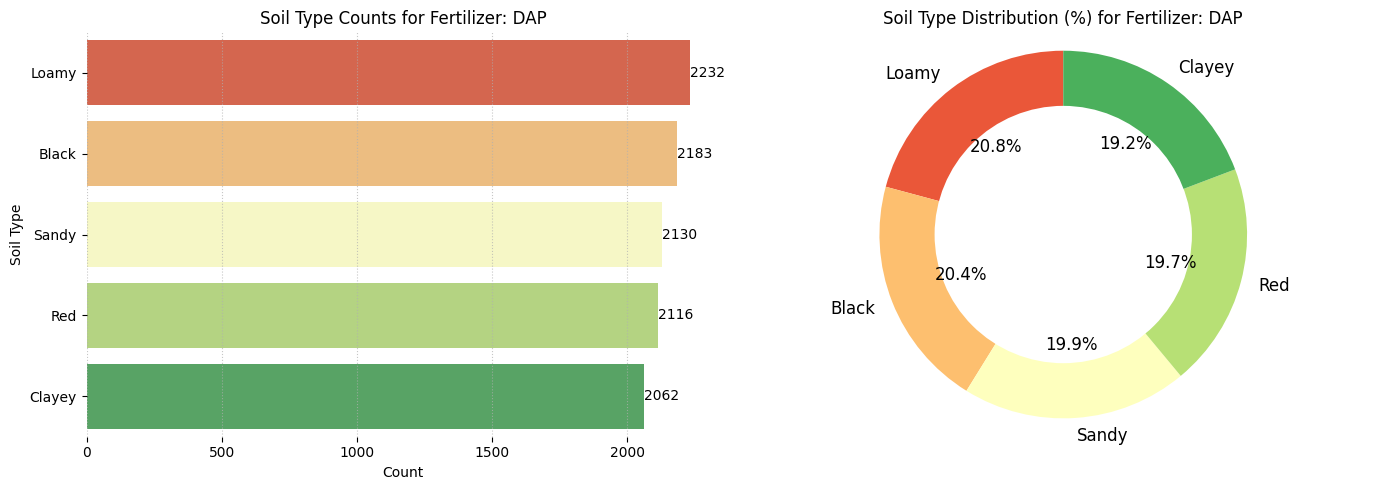

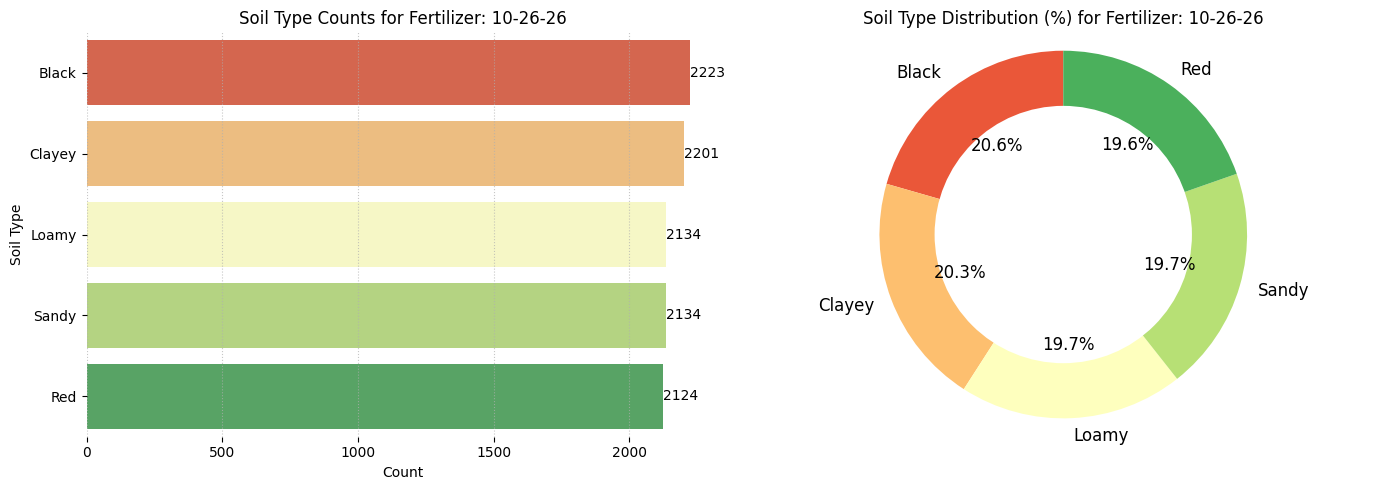

In [24]:
def plot_soil_type_distribution_by_fertilizer(data, fertilizer_class):
    filtered_data = data[data['Fertilizer Name'] == fertilizer_class]
    
    soil_order = filtered_data['Soil Type'].value_counts().index.tolist()
    
    palette = sns.color_palette("RdYlGn", n_colors=len(soil_order))
    color_mapping = dict(zip(soil_order, palette))
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    sns.countplot(
        y='Soil Type',
        data=filtered_data,
        order=soil_order,
        hue='Soil Type',           
        palette=color_mapping,
        legend=False,             
        ax=ax[0]
    )
    ax[0].set_title(f'Soil Type Counts for Fertilizer: {fertilizer_class}')
    ax[0].set_xlabel('Count')
    ax[0].set_ylabel('Soil Type')
    
    for p in ax[0].patches:
        width = int(p.get_width())
        ax[0].annotate(f'{width}',
                       (width, p.get_y() + p.get_height() / 2),
                       ha='left', va='center', fontsize=10, color='black')
    
    ax[0].grid(axis='x', linestyle=':', alpha=0.7)
    sns.despine(left=True, bottom=True, ax=ax[0])

    soil_counts = filtered_data['Soil Type'].value_counts().reindex(soil_order)
    wedges, texts, autotexts = ax[1].pie(
        soil_counts,
        labels=soil_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=[color_mapping[soil] for soil in soil_counts.index],
        textprops={'fontsize': 12}
    )
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    ax[1].add_artist(centre_circle)
    ax[1].set_title(f'Soil Type Distribution (%) for Fertilizer: {fertilizer_class}')
    ax[1].axis('equal')
    
    plt.tight_layout()
    plt.show()

unique_fertilizers = train_data['Fertilizer Name'].unique()
for fertilizer in unique_fertilizers:
    plot_soil_type_distribution_by_fertilizer(train_data, fertilizer)

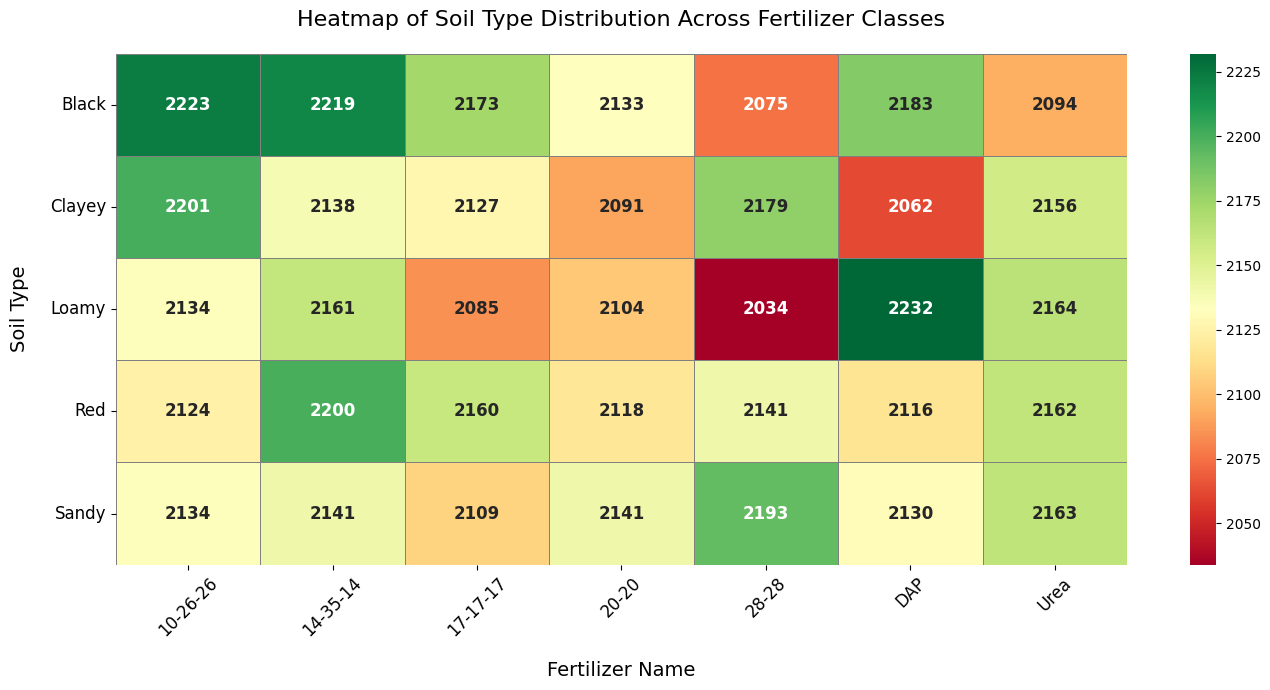

In [25]:
soil_fertilizer_crosstab = pd.crosstab(train_data['Soil Type'], train_data['Fertilizer Name'])

plt.figure(figsize=(14, 7))

heatmap = sns.heatmap(
    soil_fertilizer_crosstab,
    annot=True,
    fmt='d',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"size": 12, "weight": "bold"}  
)

heatmap.set_xticklabels(heatmap.get_xmajorticklabels(), fontsize=12, rotation=45)
heatmap.set_yticklabels(heatmap.get_ymajorticklabels(), fontsize=12, rotation=0)

plt.title('Heatmap of Soil Type Distribution Across Fertilizer Classes', fontsize=16, pad=20)
plt.xlabel('Fertilizer Name', fontsize=14, labelpad=15)
plt.ylabel('Soil Type', fontsize=14, labelpad=15)

plt.tight_layout()
plt.show()

### Insights on Soil Type Distribution Across Fertilizer Classes

**Soil Type Distribution by Fertilizer**

- The distribution of soil types within each fertilizer class is relatively balanced, with all five soil types—**Sandy, Black, Clayey, Red, and Loamy** represented in similar proportions.

**Cross-Tabulation and Heatmap Analysis**

- The cross-tabulation of **Soil Type vs Fertilizer Name** confirms that no single soil type overwhelmingly dominates any fertilizer class.  
- The heatmap visualization further illustrates this balanced distribution, with counts fairly evenly spread across soil-fertilizer pairs, indicating that fertilizer recommendations are not restricted to specific soil types alone.

**Agronomic Interpretation**

- This balanced soil distribution across fertilizer classes suggests that fertilizer recommendations are tailored considering multiple factors beyond just soil type, such as crop type, nutrient levels, and environmental conditions.  
- Different soil types have distinct physical and chemical properties affecting nutrient availability and fertilizer effectiveness. For instance:  
  - *Sandy* soils drain quickly and may require more frequent fertilization.  
  - *Clayey* soils retain nutrients longer but may limit root penetration.  
  - *Loamy* soils are generally fertile and well-balanced.  
- The presence of all soil types across fertilizers reflects a comprehensive approach to fertilizer application that considers diverse soil conditions.

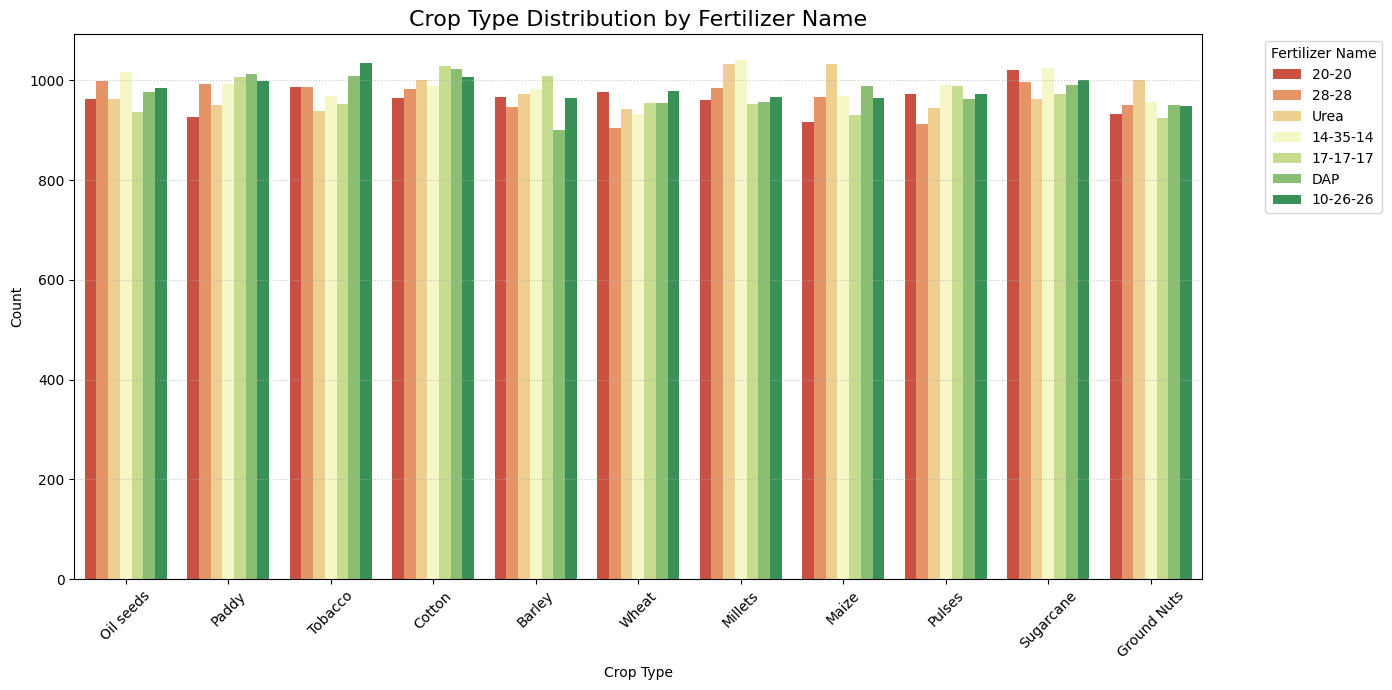

In [26]:
plot_categorical_vs_target(train_data, crop_feature, target_variable, custom_palette)

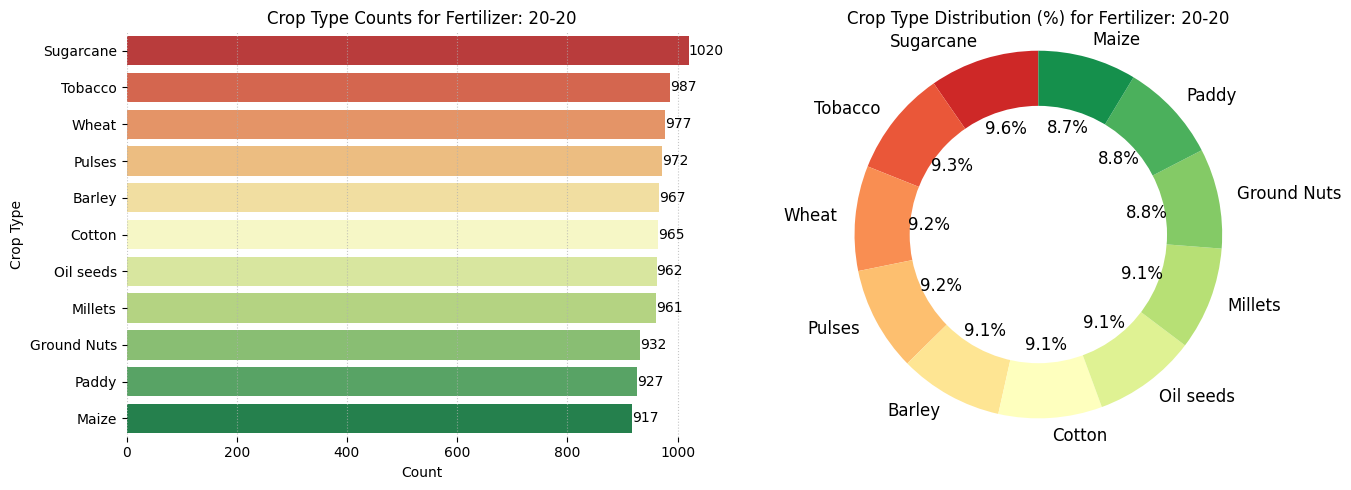

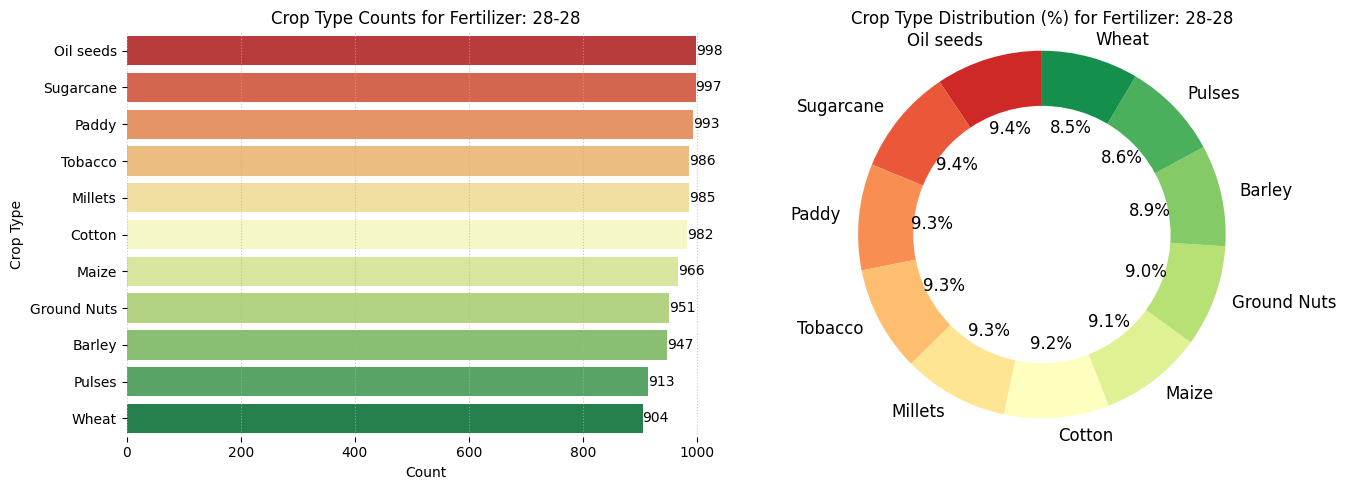

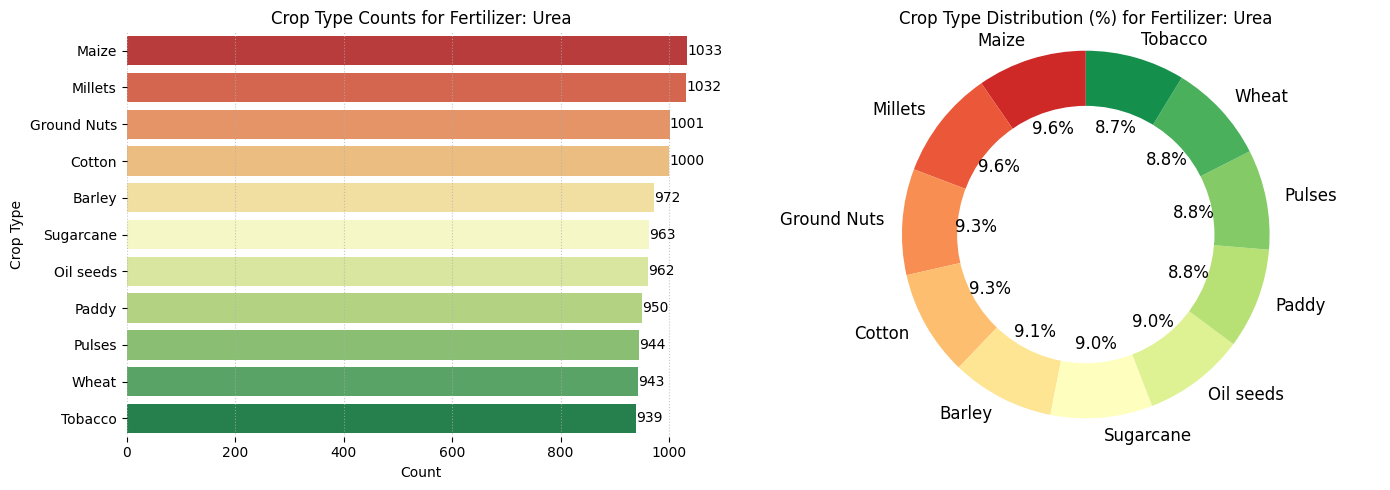

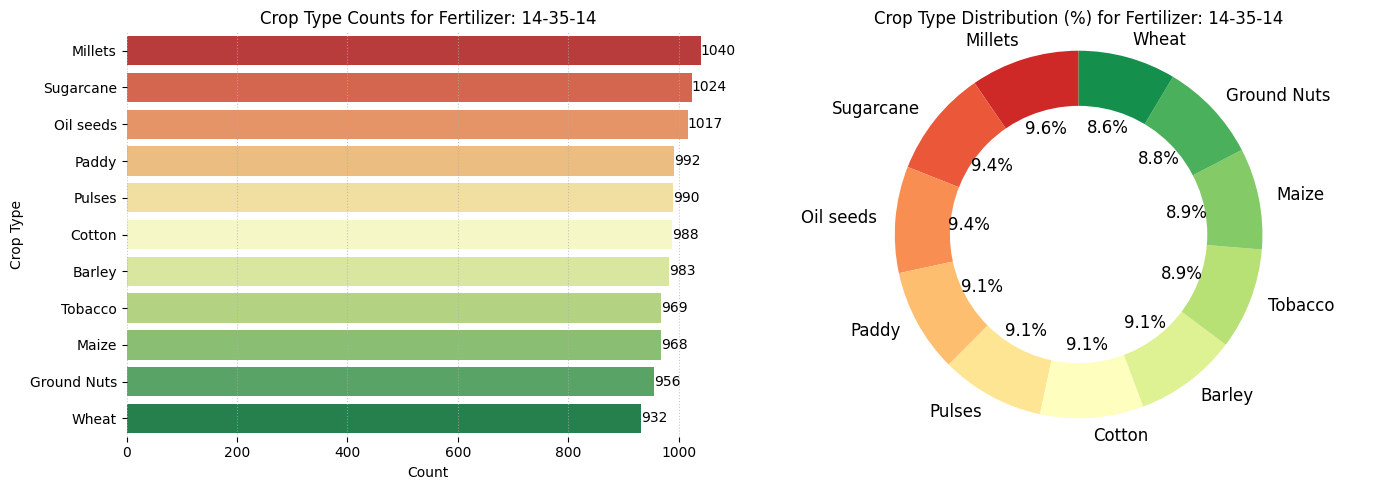

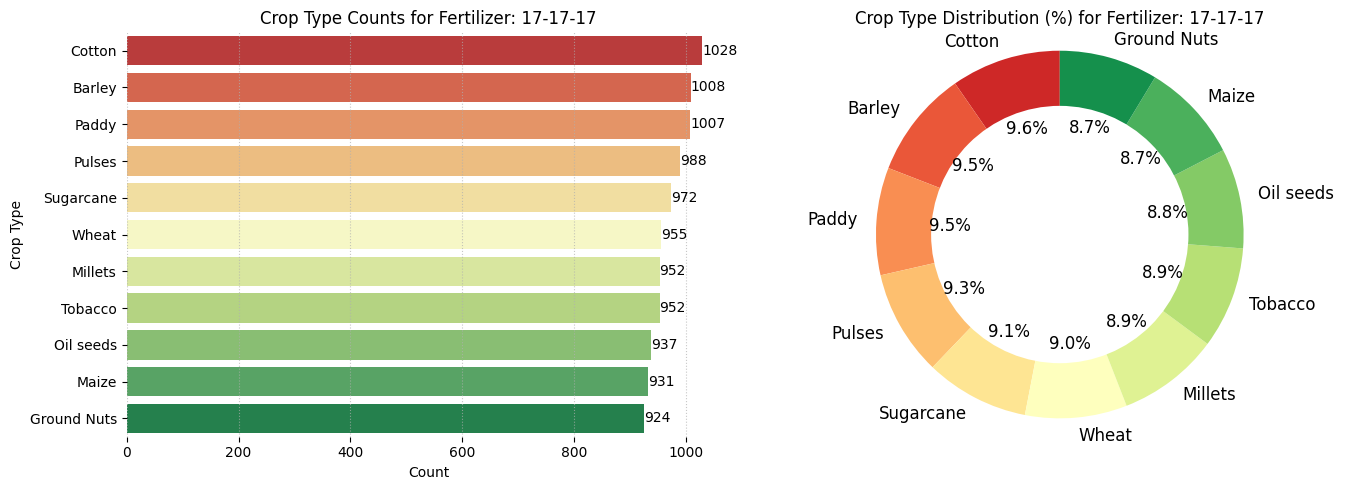

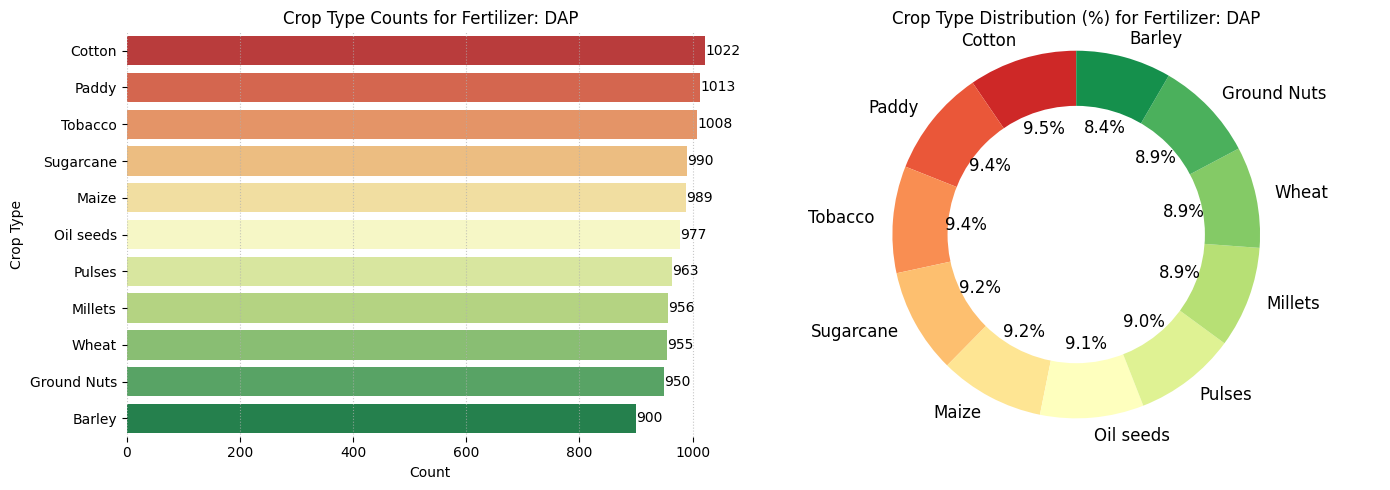

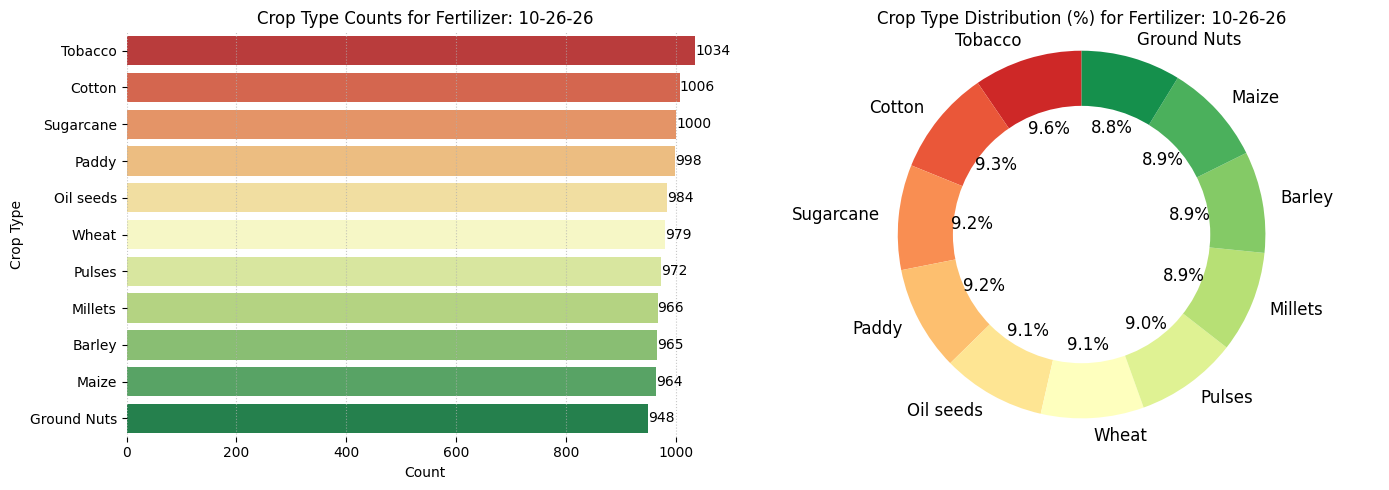

In [27]:
def plot_crop_type_distribution_by_fertilizer(data, fertilizer_class):
    filtered_data = data[data['Fertilizer Name'] == fertilizer_class]
    
    crop_order = filtered_data['Crop Type'].value_counts().index.tolist()
    
    palette = sns.color_palette("RdYlGn", n_colors=len(crop_order))
    color_mapping = dict(zip(crop_order, palette))
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.countplot(y='Crop Type', data=filtered_data, order=crop_order, hue='Crop Type', palette=color_mapping, legend=False, ax=ax[0])
    ax[0].set_title(f'Crop Type Counts for Fertilizer: {fertilizer_class}')
    ax[0].set_xlabel('Count')
    ax[0].set_ylabel('Crop Type')
    
    for p in ax[0].patches:
        ax[0].annotate(f'{int(p.get_width())}',
                       (p.get_width(), p.get_y() + p.get_height() / 2),
                       ha='left', va='center',
                       fontsize=10, color='black')
    ax[0].grid(axis='x', linestyle=':', alpha=0.7)
    sns.despine(left=True, bottom=True, ax=ax[0])
    
    crop_counts = filtered_data['Crop Type'].value_counts().reindex(crop_order)
    wedges, texts, autotexts = ax[1].pie(
        crop_counts,
        labels=crop_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=[color_mapping[crop] for crop in crop_counts.index],
        textprops={'fontsize': 12}
    )
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    ax[1].add_artist(centre_circle)
    ax[1].set_title(f'Crop Type Distribution (%) for Fertilizer: {fertilizer_class}')
    ax[1].axis('equal')
    
    plt.tight_layout()
    plt.show()

unique_fertilizers = train_data['Fertilizer Name'].unique()
for fertilizer in unique_fertilizers:
    plot_crop_type_distribution_by_fertilizer(train_data, fertilizer)

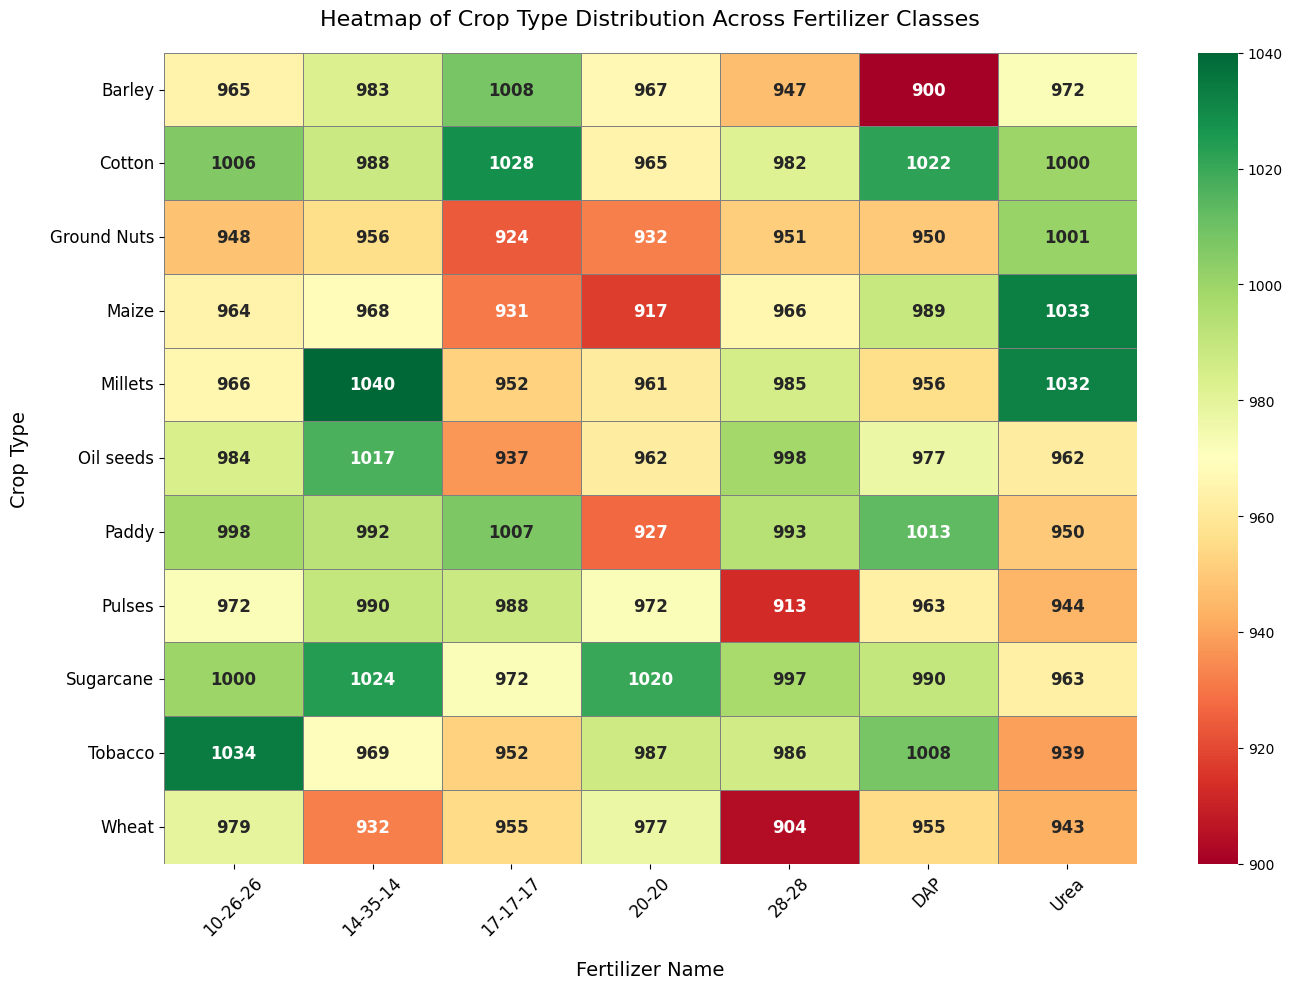

In [28]:
crop_fertilizer_crosstab = pd.crosstab(train_data['Crop Type'], train_data['Fertilizer Name'])

plt.figure(figsize=(14, 10))

heatmap = sns.heatmap(
    crop_fertilizer_crosstab,
    annot=True,
    fmt='d',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"size": 12, "weight": "bold"}  
)

heatmap.set_xticklabels(heatmap.get_xmajorticklabels(), fontsize=12, rotation=45)
heatmap.set_yticklabels(heatmap.get_ymajorticklabels(), fontsize=12, rotation=0)

plt.title('Heatmap of Crop Type Distribution Across Fertilizer Classes', fontsize=16, pad=20)
plt.xlabel('Fertilizer Name', fontsize=14, labelpad=15)
plt.ylabel('Crop Type', fontsize=14, labelpad=15)

plt.tight_layout()
plt.show()

### Insights on Fertilizer Usage Across Crop Types

**Distribution of Fertilizer Types by Crop**

- The dataset reveals that fertilizer application is broadly distributed across the 11 crop types, with no single fertilizer dominating any particular crop category.  

**Crop-Specific Fertilizer Preferences**

- While fertilizer usage is fairly balanced, some subtle preferences emerge:  
  - **Pulses** tend to have a slightly higher proportion of `17-17-17` and `14-35-14` fertilizers, which may relate to their nitrogen-fixing properties and nutrient requirements.  
  - **Sugarcane** and **Tobacco** show consistent use across fertilizers but with slightly lower counts for `Urea`, possibly reflecting crop-specific nitrogen management.  
  - **Maize** and **Ground Nuts** have relatively lower fertilizer counts overall, which might be due to crop rotation practices or soil fertility considerations.

## Soil Nutrient Levels by Fertilizer Classes

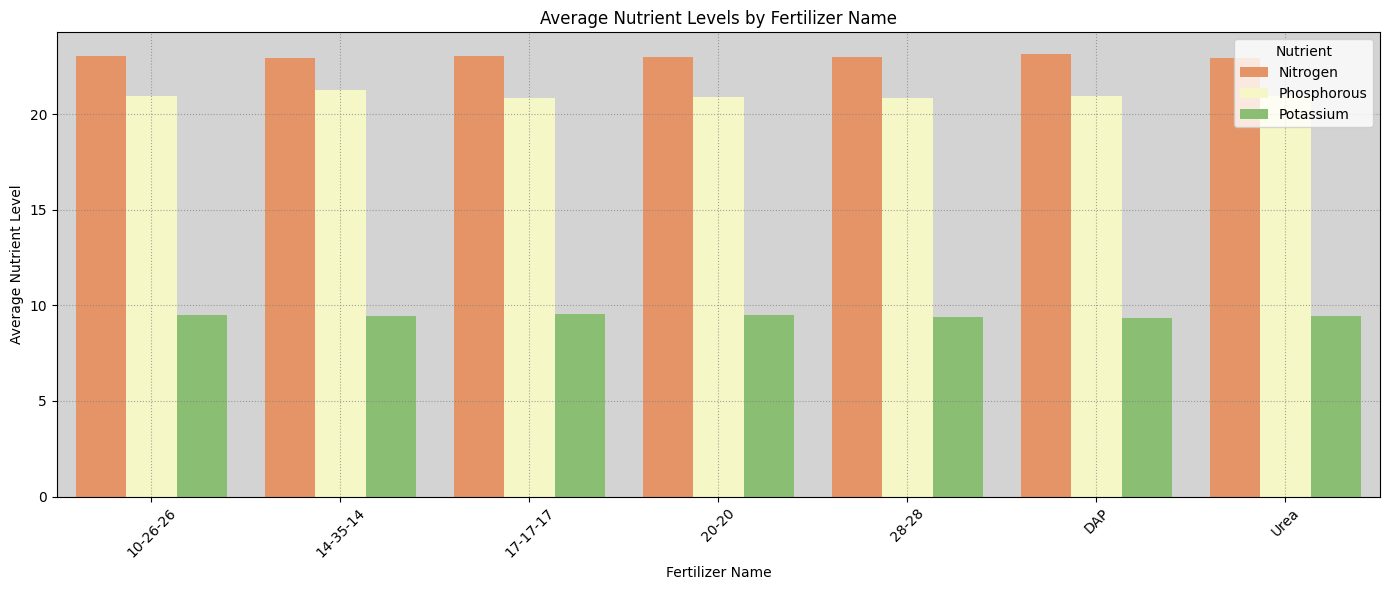

In [29]:
mean_nutrients = train_data.groupby(target_variable)[nutrient_features].mean().reset_index()
mean_nutrients_melted = mean_nutrients.melt(id_vars=target_variable, var_name='Nutrient', value_name='Mean Level')

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=mean_nutrients_melted, x=target_variable, y='Mean Level', hue='Nutrient', palette='RdYlGn', ax=ax)
ax.set_title(f'Average Nutrient Levels by {target_variable}')
ax.set_xlabel(target_variable)
ax.set_ylabel('Average Nutrient Level')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Nutrient')
ax.set_facecolor('lightgray')
ax.grid(color='gray', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [30]:
def nutrient_summary_by_target(df, target_variable, nutrient_features):
    print("=" * 60)
    print(f"Summary Statistics of Nutrients by {target_variable}")
    print("=" * 60)
    
    for feature in nutrient_features:
        summary_stats = df.groupby(target_variable)[feature].describe().round(2)
        print(f"\n--- {feature} ---\n")
        display(summary_stats)

nutrient_summary_by_target(train_data, target_variable, nutrient_features)

Summary Statistics of Nutrients by Fertilizer Name

--- Nitrogen ---



,count,mean,std,min,25%,50%,75%,max
Fertilizer Name,,,,,,,,
10-26-26,10816.0,23.03,11.28,4.0,13.0,23.0,33.0,42.0
14-35-14,10859.0,22.93,11.17,4.0,13.0,23.0,33.0,42.0
17-17-17,10654.0,23.03,11.25,4.0,13.0,23.0,33.0,42.0
20-20,10587.0,23.00,11.26,4.0,13.0,23.0,33.0,42.0
28-28,10622.0,23.00,11.26,4.0,13.0,23.0,33.0,42.0
DAP,10723.0,23.13,11.28,4.0,13.0,23.0,33.0,42.0
Urea,10739.0,22.95,11.27,4.0,13.0,23.0,33.0,42.0



--- Phosphorous ---



,count,mean,std,min,25%,50%,75%,max
Fertilizer Name,,,,,,,,
10-26-26,10816.0,20.95,12.39,0.0,10.0,21.0,31.25,42.0
14-35-14,10859.0,21.29,12.42,0.0,11.0,21.0,32.00,42.0
17-17-17,10654.0,20.84,12.34,0.0,10.0,21.0,31.00,42.0
20-20,10587.0,20.92,12.35,0.0,10.0,21.0,31.00,42.0
28-28,10622.0,20.85,12.44,0.0,10.0,21.0,32.00,42.0
DAP,10723.0,20.96,12.39,0.0,10.0,21.0,32.00,42.0
Urea,10739.0,20.98,12.42,0.0,10.0,21.0,32.00,42.0



--- Potassium ---



,count,mean,std,min,25%,50%,75%,max
Fertilizer Name,,,,,,,,
10-26-26,10816.0,9.52,5.81,0.0,4.0,10.0,15.0,19.0
14-35-14,10859.0,9.47,5.76,0.0,4.0,9.0,14.0,19.0
17-17-17,10654.0,9.53,5.79,0.0,5.0,10.0,15.0,19.0
20-20,10587.0,9.51,5.80,0.0,4.0,9.0,15.0,19.0
28-28,10622.0,9.40,5.75,0.0,4.0,9.0,14.0,19.0
DAP,10723.0,9.36,5.77,0.0,4.0,9.0,14.0,19.0
Urea,10739.0,9.44,5.77,0.0,4.0,9.0,14.0,19.0


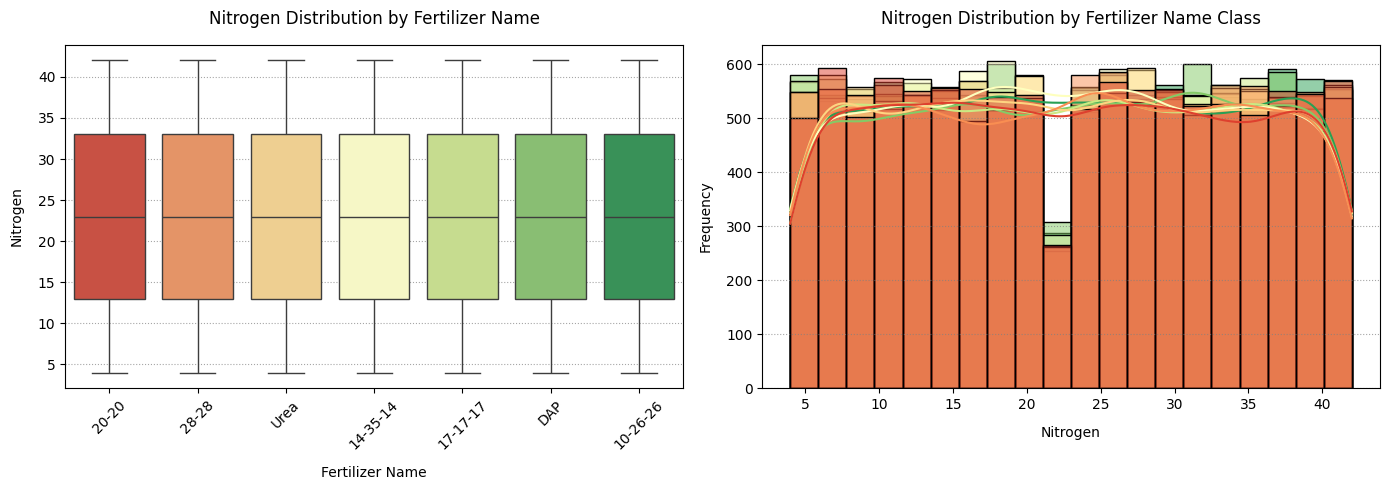

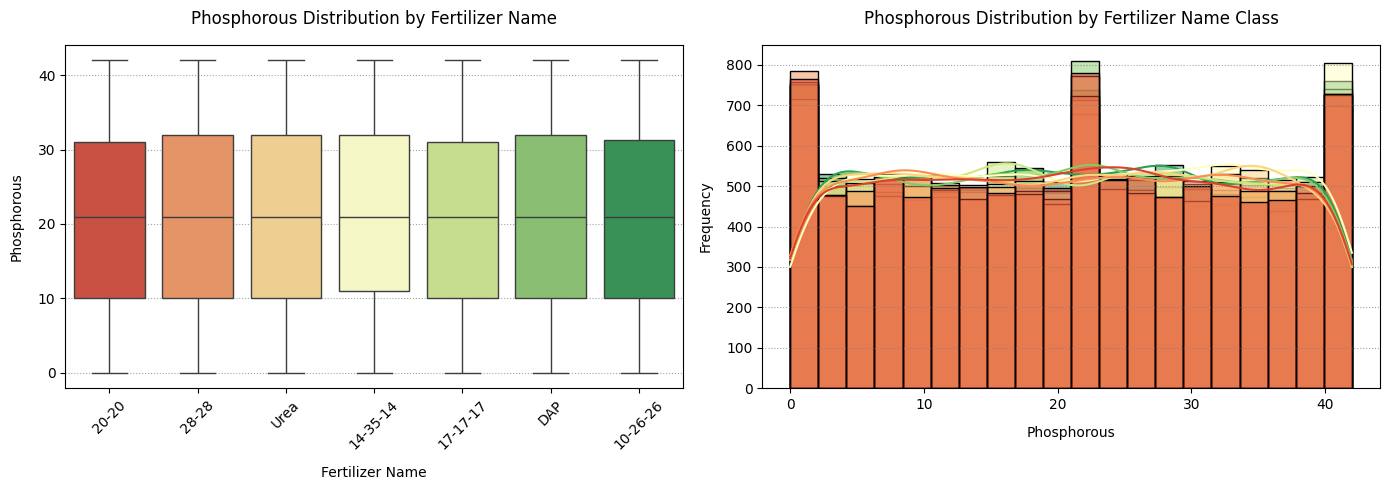

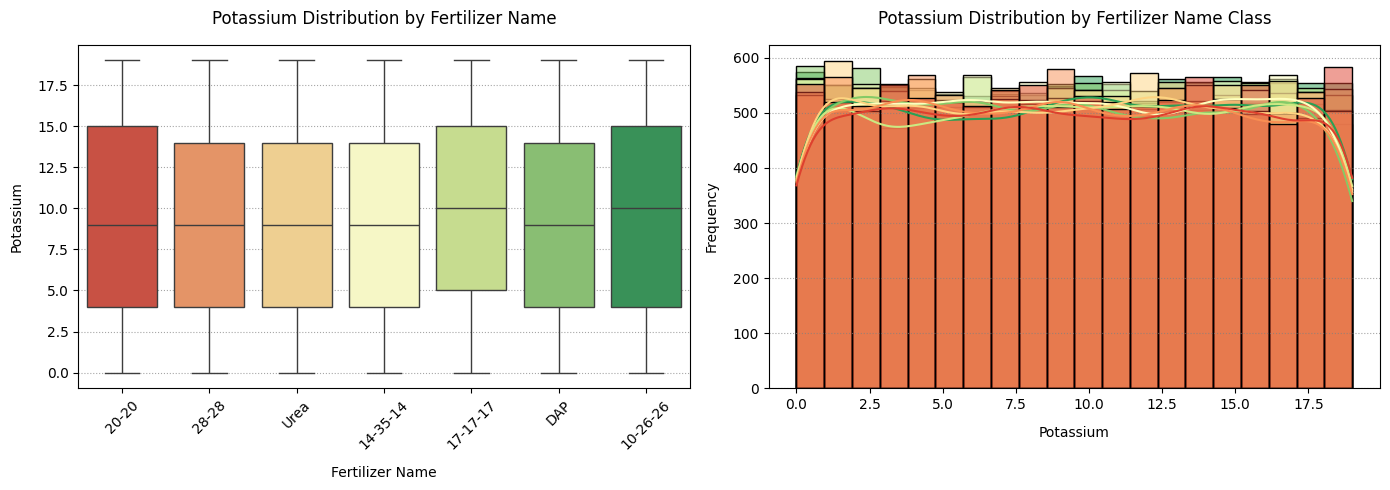

In [31]:
custom_palette = sns.color_palette("RdYlGn", len(train_data[target_variable].unique()))

for feature in nutrient_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.boxplot(x=target_variable, y=feature, data=train_data, hue=target_variable,
                palette=custom_palette, legend=False, ax=axes[0])
    axes[0].set_title(f'{feature} Distribution by {target_variable}', pad=15)
    axes[0].set_xlabel(target_variable, labelpad=10)
    axes[0].set_ylabel(feature, labelpad=10)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', color='gray', linestyle=':', alpha=0.7)
    
    sns.histplot(data=train_data, x=feature, hue=target_variable, 
                 bins=20, palette=custom_palette, ax=axes[1], kde=True, legend=False)
    axes[1].set_title(f'{feature} Distribution by {target_variable} Class', pad=15)
    axes[1].set_xlabel(feature, labelpad=10)
    axes[1].set_ylabel('Frequency', labelpad=10)
    axes[1].grid(axis='y', color='gray', linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

#### Insights on Soil Nutrient Levels by Fertilizer Type

**Average Nutrient Levels Across Fertilizers**

- The barplot displays the average levels of key soil nutrients—**Nitrogen (N), Phosphorous (P), and Potassium (K)**—grouped by fertilizer type.  
- Nutrient levels are generally similar across fertilizers, with mean nitrogen values around **23 units**, phosphorous near **20.9 units**, and potassium approximately **9.36 to 9.53 units**.  
- This suggests that the soil nutrient availability associated with each fertilizer class is fairly balanced, indicating that fertilizer choice is influenced by factors beyond just nutrient levels.

**Distribution and Variability of Nutrients**

- The boxplots and histograms reveal overlapping distributions of nutrient levels across fertilizer types, with no fertilizer showing extreme deviations.  
- For example, nitrogen levels range consistently from 4 to 42 units across fertilizers, with similar interquartile ranges.  
- Phosphorous and potassium also show stable distributions, reflecting balanced soil fertility conditions in the dataset.

***The dataset presents balanced soil nutrient profiles across fertilizer classes, providing a solid foundation for modeling fertilizer recommendations.  
Understanding nutrient distributions in relation to fertilizer types enhances model interpretability and supports environmentally responsible fertilization practices.***

## Soil Nutrient Levels by Soil Type

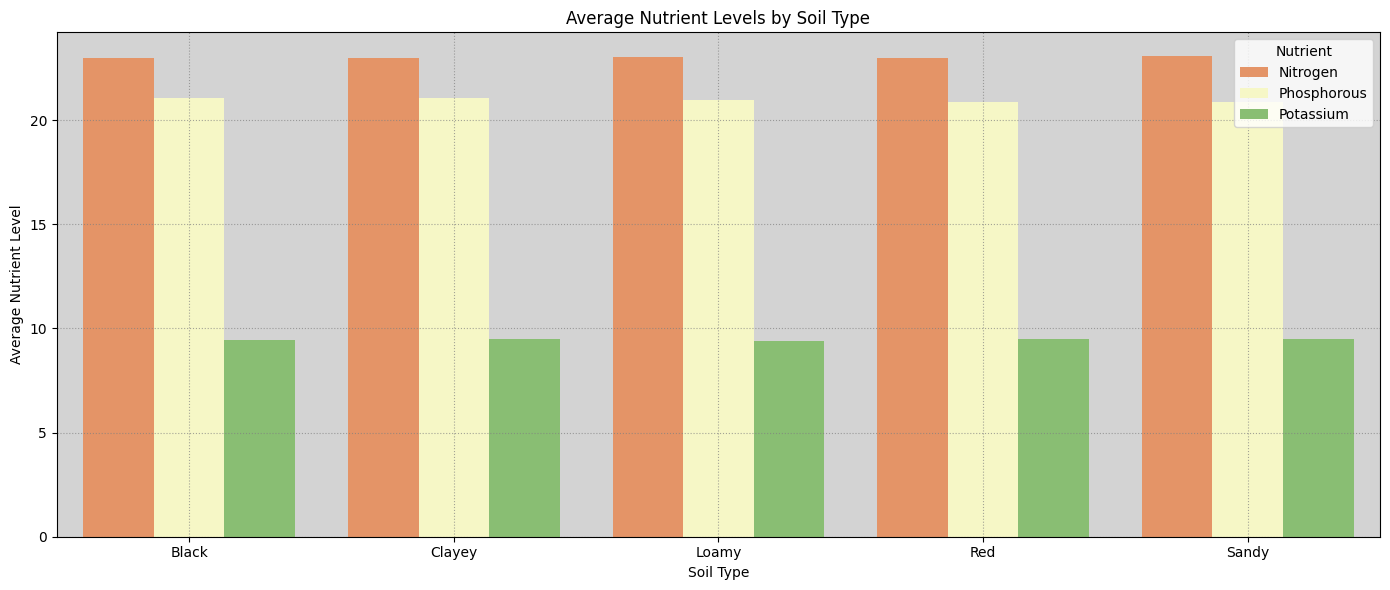

In [32]:
mean_nutrients = train_data.groupby('Soil Type')[nutrient_features].mean().reset_index()
mean_nutrients_melted = mean_nutrients.melt(id_vars='Soil Type', var_name='Nutrient', value_name='Mean Level')

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=mean_nutrients_melted, x='Soil Type', y='Mean Level', hue='Nutrient', palette='RdYlGn', ax=ax)
ax.set_title('Average Nutrient Levels by Soil Type')
ax.set_xlabel('Soil Type')
ax.set_ylabel('Average Nutrient Level')
ax.legend(title='Nutrient')
ax.set_facecolor('lightgray')
ax.grid(color='gray', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [33]:
def nutrient_summary_by_soil(df, soil_feature, nutrient_features):
    print("=" * 55)
    print(f"Summary Statistics of Nutrients by {soil_feature}")
    print("=" * 55)
    
    for nutrient in nutrient_features:
        summary_stats = df.groupby(soil_feature)[nutrient].describe().round(2)
        print(f"\n--- {nutrient} ---\n")
        display(summary_stats)

nutrient_summary_by_soil(train_data, soil_feature, nutrient_features)

Summary Statistics of Nutrients by Soil Type

--- Nitrogen ---



,count,mean,std,min,25%,50%,75%,max
Soil Type,,,,,,,,
Black,15100.0,22.98,11.34,4.0,13.0,23.0,33.0,42.0
Clayey,14954.0,23.00,11.25,4.0,13.0,23.0,33.0,42.0
Loamy,14914.0,23.05,11.20,4.0,14.0,23.0,33.0,42.0
Red,15021.0,22.96,11.26,4.0,13.0,23.0,33.0,42.0
Sandy,15011.0,23.06,11.20,4.0,13.0,23.0,33.0,42.0



--- Phosphorous ---



,count,mean,std,min,25%,50%,75%,max
Soil Type,,,,,,,,
Black,15100.0,21.05,12.39,0.0,10.0,21.0,32.0,42.0
Clayey,14954.0,21.07,12.39,0.0,10.0,21.0,32.0,42.0
Loamy,14914.0,20.98,12.32,0.0,10.0,21.0,32.0,42.0
Red,15021.0,20.88,12.36,0.0,10.0,21.0,32.0,42.0
Sandy,15011.0,20.87,12.49,0.0,10.0,21.0,32.0,42.0



--- Potassium ---



,count,mean,std,min,25%,50%,75%,max
Soil Type,,,,,,,,
Black,15100.0,9.43,5.79,0.0,4.0,9.0,14.0,19.0
Clayey,14954.0,9.51,5.79,0.0,4.0,10.0,15.0,19.0
Loamy,14914.0,9.39,5.79,0.0,4.0,9.0,14.0,19.0
Red,15021.0,9.48,5.76,0.0,4.0,9.0,14.0,19.0
Sandy,15011.0,9.50,5.76,0.0,5.0,10.0,14.0,19.0


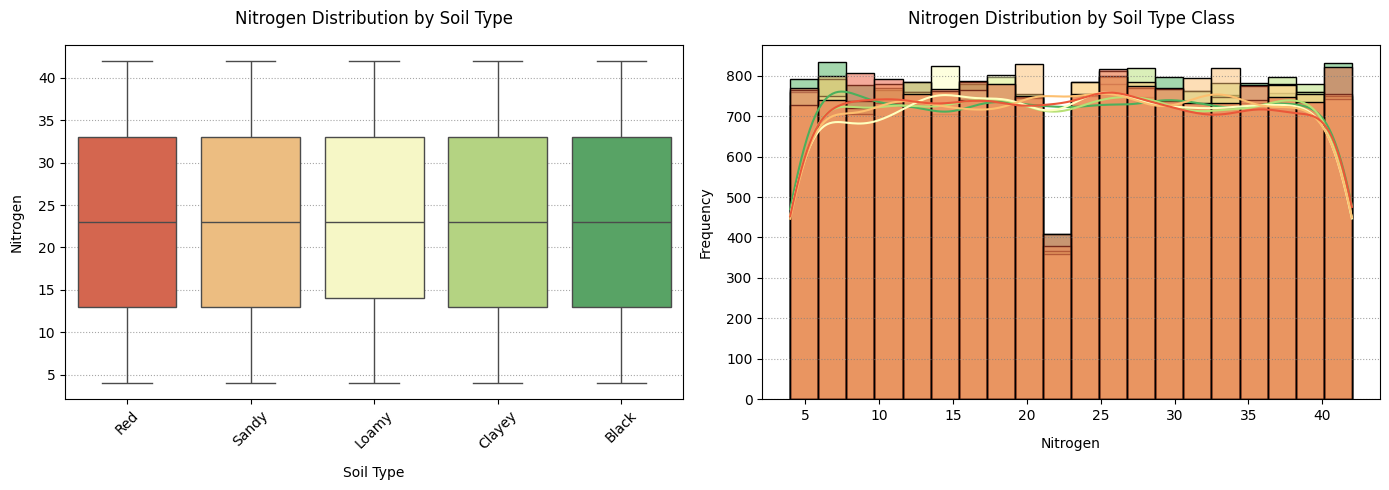

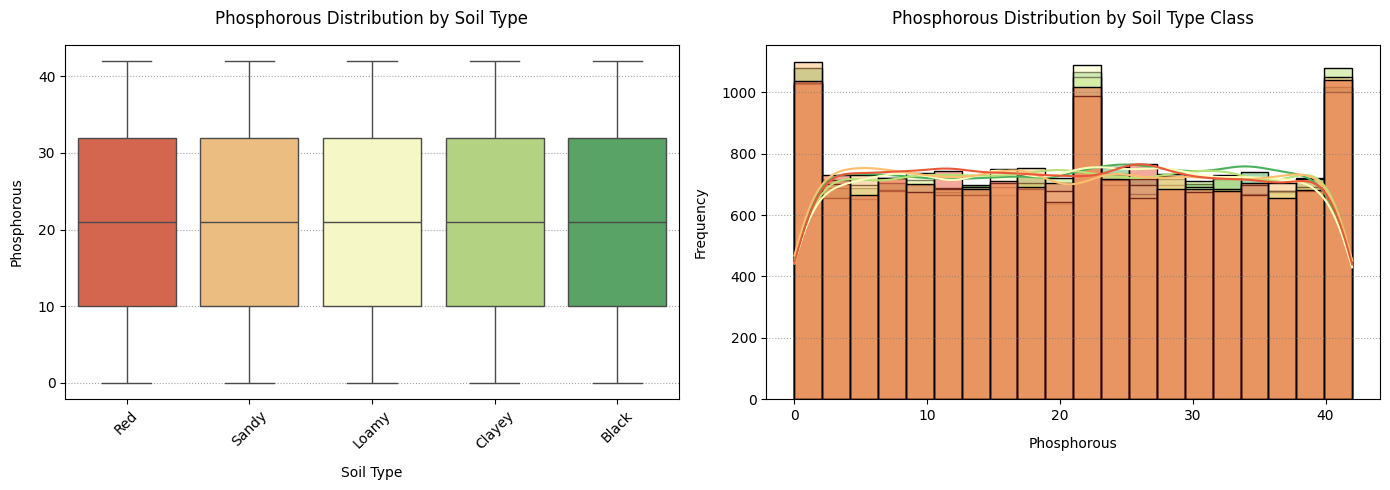

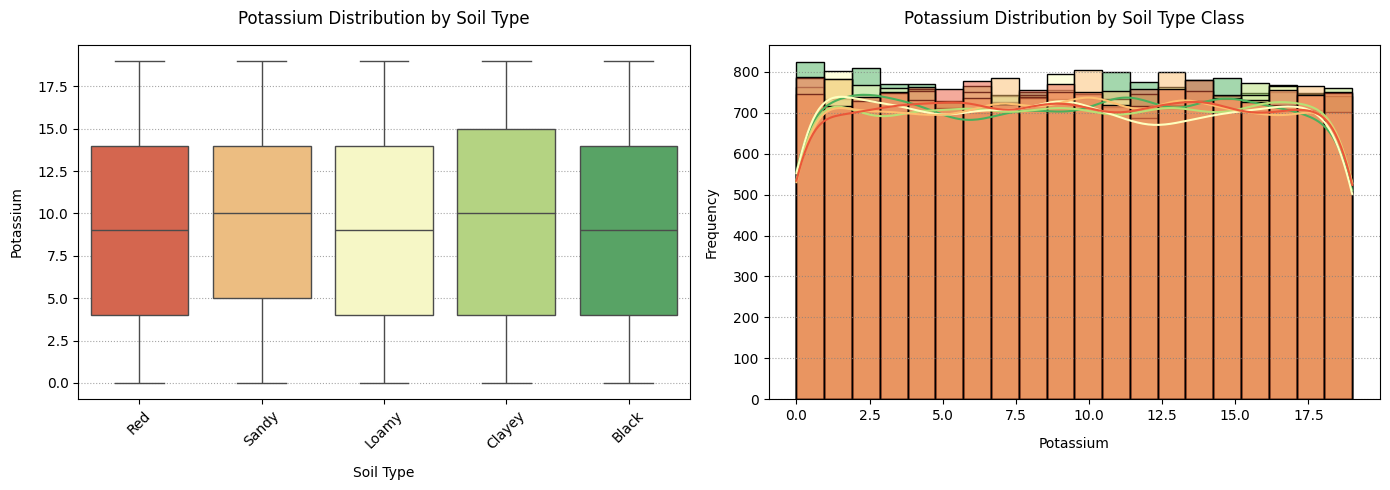

In [34]:
custom_palette_soil = sns.color_palette("RdYlGn", len(train_data[soil_feature].unique()))

for feature in nutrient_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.boxplot(x=soil_feature, y=feature, data=train_data, hue=soil_feature,
                palette=custom_palette_soil, ax=axes[0], legend=False)
    axes[0].set_title(f'{feature} Distribution by {soil_feature}', pad=15)
    axes[0].set_xlabel(soil_feature, labelpad=10)
    axes[0].set_ylabel(feature, labelpad=10)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', color='gray', linestyle=':', alpha=0.7)

    sns.histplot(data=train_data, x=feature, hue=soil_feature, 
                 bins=20, palette=custom_palette_soil, ax=axes[1], kde=True, legend=False)
    axes[1].set_title(f'{feature} Distribution by {soil_feature} Class', pad=15)
    axes[1].set_xlabel(feature, labelpad=10)
    axes[1].set_ylabel('Frequency', labelpad=10)
    axes[1].grid(axis='y', color='gray', linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

### Insights on Soil Nutrient Levels by Soil Type

**Average Nutrient Levels Across Soil Types**

- The barplot shows the average levels of key soil nutrients—**Nitrogen (N), Phosphorous (P), and Potassium (K)**—across the five soil types: *Black, Clayey, Loamy, Red,* and *Sandy*.  
- Nutrient levels are remarkably consistent across soil types, with mean nitrogen values around **23 units**, phosphorous around **21 units**, and potassium near **9.4 to 9.5 units**.  
- This uniformity suggests that nutrient availability is fairly balanced across the soil types represented in the dataset.

**Distribution and Variability of Nutrients**

- The boxplots and histograms reveal that while mean nutrient levels are similar, there is some variation in nutrient distributions within soil types.  
- The nutrient ranges (min to max) are consistent across soil types, indicating similar nutrient availability extremes.

***The dataset provides a balanced representation of soil nutrient levels across major soil types, offering a solid foundation for modeling fertilizer recommendations.***

## Soil Nutrient Levels by Crop Type

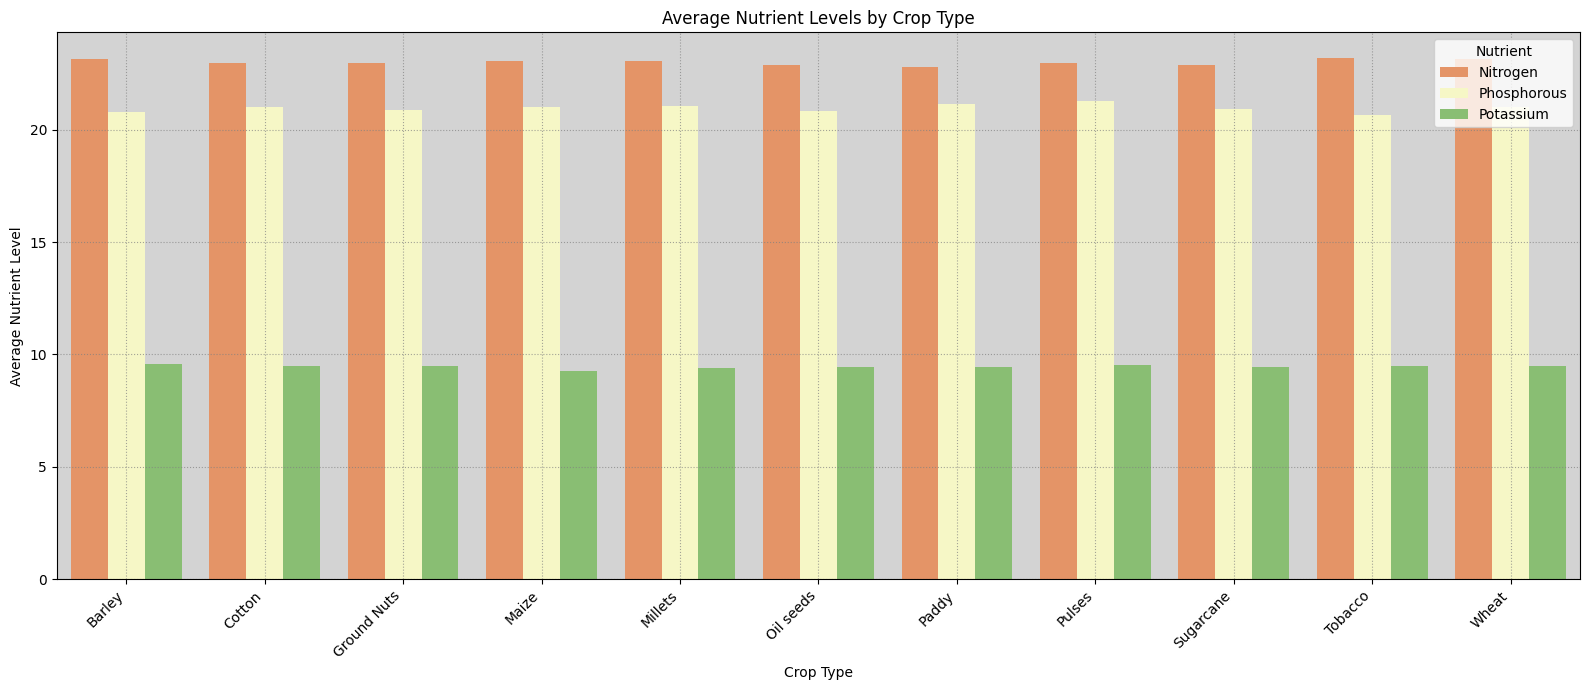

In [35]:
mean_nutrients_crop = train_data.groupby('Crop Type')[nutrient_features].mean().reset_index()
mean_nutrients_crop_melted = mean_nutrients_crop.melt(id_vars='Crop Type', var_name='Nutrient', value_name='Mean Level')

fig, ax = plt.subplots(figsize=(16, 7))
sns.barplot(data=mean_nutrients_crop_melted, x='Crop Type', y='Mean Level', hue='Nutrient', palette='RdYlGn', ax=ax)

ax.set_title('Average Nutrient Levels by Crop Type')
ax.set_xlabel('Crop Type')
ax.set_ylabel('Average Nutrient Level')
ax.legend(title='Nutrient')
ax.set_facecolor('lightgray')
ax.grid(color='gray', linestyle=':', alpha=0.7)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [36]:
def nutrient_summary_by_crop(df, crop_feature, nutrient_features):
    print("=" * 55)
    print(f"Summary Statistics of Nutrients by {crop_feature}")
    print("=" * 55)
    
    for nutrient in nutrient_features:
        summary_stats = df.groupby(crop_feature)[nutrient].describe().round(2)
        print(f"\n--- {nutrient} ---\n")
        display(summary_stats)

nutrient_summary_by_crop(train_data, crop_feature, nutrient_features)

Summary Statistics of Nutrients by Crop Type

--- Nitrogen ---



,count,mean,std,min,25%,50%,75%,max
Crop Type,,,,,,,,
Barley,6742.0,23.16,11.09,4.0,14.0,23.0,33.0,42.0
Cotton,6991.0,22.98,11.31,4.0,13.0,23.0,33.0,42.0
Ground Nuts,6662.0,22.98,11.21,4.0,13.0,23.0,33.0,42.0
Maize,6768.0,23.06,11.20,4.0,13.0,23.0,33.0,42.0
Millets,6892.0,23.07,11.25,4.0,13.0,23.0,33.0,42.0
Oil seeds,6837.0,22.87,11.24,4.0,13.0,23.0,33.0,42.0
Paddy,6880.0,22.78,11.34,4.0,13.0,23.0,33.0,42.0
Pulses,6742.0,22.98,11.28,4.0,13.0,23.0,33.0,42.0
Sugarcane,6966.0,22.89,11.24,4.0,13.0,23.0,33.0,42.0



--- Phosphorous ---



,count,mean,std,min,25%,50%,75%,max
Crop Type,,,,,,,,
Barley,6742.0,20.81,12.42,0.0,10.0,21.0,32.0,42.0
Cotton,6991.0,21.04,12.33,0.0,10.0,21.0,32.0,42.0
Ground Nuts,6662.0,20.87,12.36,0.0,10.0,21.0,31.0,42.0
Maize,6768.0,21.00,12.41,0.0,10.0,21.0,32.0,42.0
Millets,6892.0,21.06,12.26,0.0,11.0,21.0,32.0,42.0
Oil seeds,6837.0,20.86,12.39,0.0,10.0,21.0,32.0,42.0
Paddy,6880.0,21.15,12.44,0.0,10.0,21.0,32.0,42.0
Pulses,6742.0,21.30,12.44,0.0,10.0,21.0,32.0,42.0
Sugarcane,6966.0,20.91,12.47,0.0,10.0,21.0,32.0,42.0



--- Potassium ---



,count,mean,std,min,25%,50%,75%,max
Crop Type,,,,,,,,
Barley,6742.0,9.59,5.76,0.0,5.00,10.0,15.0,19.0
Cotton,6991.0,9.50,5.79,0.0,4.00,10.0,14.0,19.0
Ground Nuts,6662.0,9.48,5.77,0.0,4.25,9.0,14.0,19.0
Maize,6768.0,9.28,5.78,0.0,4.00,9.0,14.0,19.0
Millets,6892.0,9.40,5.78,0.0,4.00,9.0,14.0,19.0
Oil seeds,6837.0,9.46,5.82,0.0,4.00,9.0,15.0,19.0
Paddy,6880.0,9.45,5.79,0.0,4.00,9.0,15.0,19.0
Pulses,6742.0,9.52,5.74,0.0,5.00,10.0,15.0,19.0
Sugarcane,6966.0,9.44,5.77,0.0,4.25,9.0,14.0,19.0


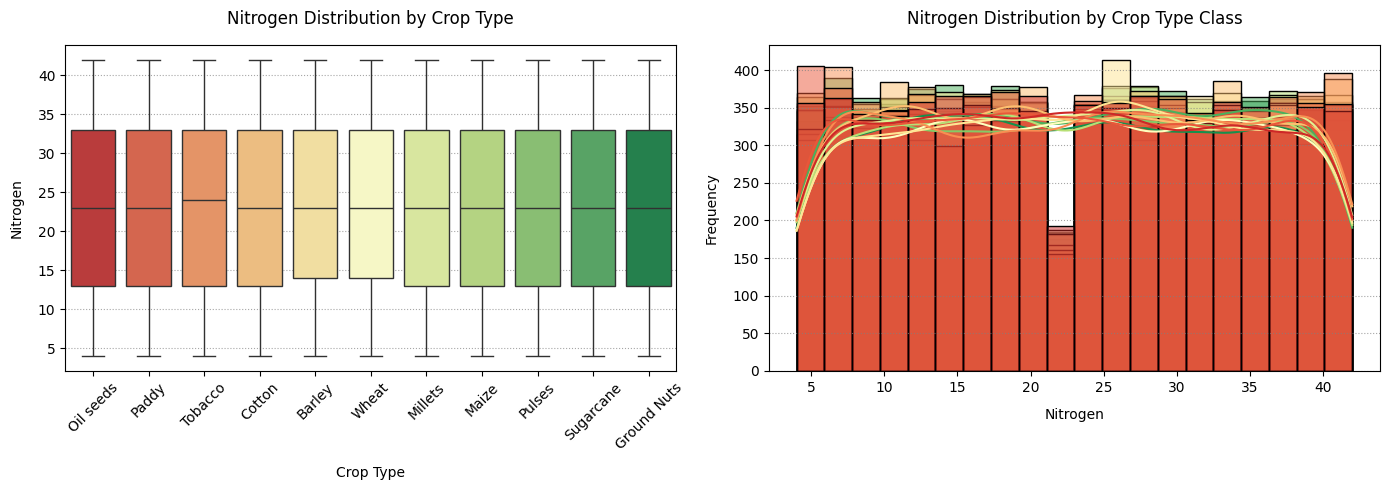

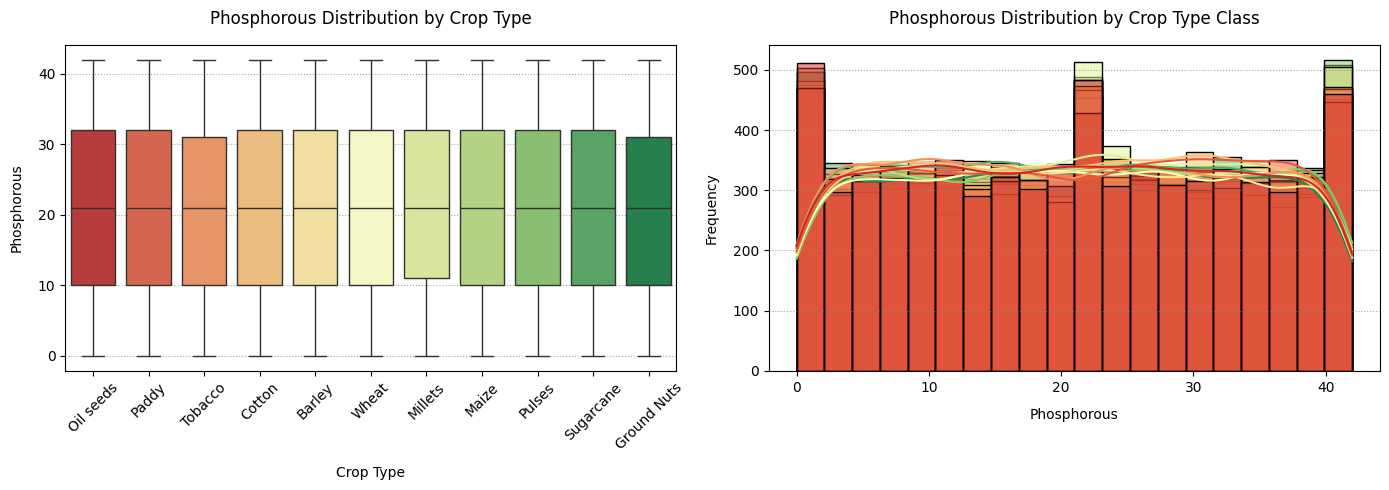

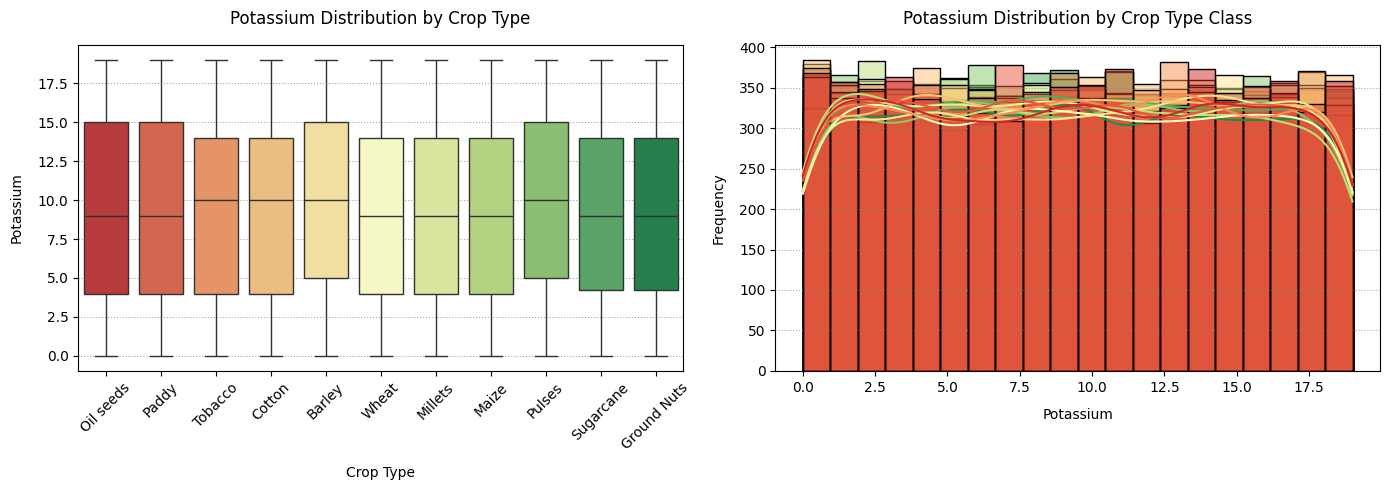

In [37]:
custom_palette_crop = sns.color_palette("RdYlGn", len(train_data[crop_feature].unique()))

for feature in nutrient_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.boxplot(x=crop_feature, y=feature, data=train_data, hue=crop_feature, palette=custom_palette_crop, legend=False, ax=axes[0])
    axes[0].set_title(f'{feature} Distribution by {crop_feature}', pad=15)
    axes[0].set_xlabel(crop_feature, labelpad=10)
    axes[0].set_ylabel(feature, labelpad=10)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', color='gray', linestyle=':', alpha=0.7)

    sns.histplot(data=train_data, x=feature, hue=crop_feature, bins=20, palette=custom_palette_crop, ax=axes[1], kde=True, legend=False)
    axes[1].set_title(f'{feature} Distribution by {crop_feature} Class', pad=15)
    axes[1].set_xlabel(feature, labelpad=10)
    axes[1].set_ylabel('Frequency', labelpad=10)
    axes[1].grid(axis='y', color='gray', linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

### Insights on Soil Nutrient Levels by Crop Type

**Average Nutrient Levels Across Crop Types**

- The barplot illustrates the average levels of key soil nutrients—**Nitrogen (N), Phosphorous (P), and Potassium (K)**—across the 11 crop types in the dataset.  
- Nutrient levels are generally consistent across crops, with mean nitrogen values around **23 units**, phosphorous near **21 units**, and potassium roughly **9.4 to 9.6 units**.  
- This suggests that the soil nutrient availability is relatively uniform across the different cropping systems represented.

**Distribution and Variability of Nutrients**

- Boxplots and histograms reveal some variation in nutrient distributions within crop types, reflecting differences in nutrient uptake, fertilization practices, and soil conditions associated with each crop.  

***The dataset presents a comprehensive profile of soil nutrient availability across diverse crop types, providing a strong basis for fertilizer recommendation modeling.***

## Data Preprocessing

In [38]:
categorical_features = ['Soil Type', 'Crop Type']

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    train_data[col + '_Encoded'] = le.fit_transform(train_data[col])
    label_encoders[col] = le
    
    test_data[col + '_Encoded'] = test_data[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

    print(f"\nEncoding mapping for {col}:")
    for cat, code in zip(le.classes_, le.transform(le.classes_)):
        print(f"  {cat} --> {code}")

target_le = LabelEncoder()
train_data[target_variable + '_Encoded'] = target_le.fit_transform(train_data[target_variable])

print("\nTarget encoding mapping:")
for cat, code in zip(target_le.classes_, target_le.transform(target_le.classes_)):
    print(f"  {cat} --> {code}")

train_data.drop(columns=categorical_features, inplace=True)
test_data.drop(columns=categorical_features, inplace=True)

train_data.drop(columns=[target_variable], inplace=True)
test_data.drop(columns=[target_variable], inplace=True)


Encoding mapping for Soil Type:
  Black --> 0
  Clayey --> 1
  Loamy --> 2
  Red --> 3
  Sandy --> 4

Encoding mapping for Crop Type:
  Barley --> 0
  Cotton --> 1
  Ground Nuts --> 2
  Maize --> 3
  Millets --> 4
  Oil seeds --> 5
  Paddy --> 6
  Pulses --> 7
  Sugarcane --> 8
  Tobacco --> 9
  Wheat --> 10

Target encoding mapping:
  10-26-26 --> 0
  14-35-14 --> 1
  17-17-17 --> 2
  20-20 --> 3
  28-28 --> 4
  DAP --> 5
  Urea --> 6


- Categorical variables, specifically **Soil Type** and **Crop Type**, were label encoded to convert textual categories into numerical codes compatible with machine learning algorithms.  
- The encoding mappings were consistent and comprehensive, covering all categories in the training and test datasets.  
- The target variable, **Fertilizer Name**, was also label encoded to facilitate model training on a numerical target.  
- Original categorical columns were dropped post-encoding to avoid redundancy.

## Removing Whitespaces in Feature Names

In [39]:
train_data.columns = train_data.columns.str.replace(' ', '_', regex=True)
test_data.columns = test_data.columns.str.replace(' ', '_', regex=True)

print("Updated Feature Names in train_data:")
print(train_data.columns)

print("\nUpdated Feature Names in test_data:")
print(test_data.columns)

Updated Feature Names in train_data:
Index(['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium',
       'Phosphorous', 'Soil_Type_Encoded', 'Crop_Type_Encoded',
       'Fertilizer_Name_Encoded'],
      dtype='object')

Updated Feature Names in test_data:
Index(['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium',
       'Phosphorous', 'Soil_Type_Encoded', 'Crop_Type_Encoded'],
      dtype='object')


- Whitespaces in feature names were removed and replaced with underscores to ensure consistency and avoid errors during data processing and modeling.  
- This step improves code readability and compatibility across different libraries and environments.

## Verifying Data Types Across Datasets

In [40]:
train_data_types = pd.DataFrame({
    'Column Name': train_data.columns,
    'Combined Data Type': train_data.dtypes.astype(str)  
})

test_data_types = pd.DataFrame({
    'Column Name': test_data.columns,
    'Test Data Type': test_data.dtypes.astype(str)
})

data_types_comparison = pd.merge(
    train_data_types,
    test_data_types,
    on='Column Name',
    how='outer'  
)

print("Data Types Comparison of Combined and Test Datasets:\n")
display(data_types_comparison)

Data Types Comparison of Combined and Test Datasets:



,Column Name,Combined Data Type,Test Data Type
0,Crop_Type_Encoded,int64,int64
1,Fertilizer_Name_Encoded,int64,NaN
2,Humidity,int64,int64
3,Moisture,int64,int64
4,Nitrogen,int64,int64
5,Phosphorous,int64,int64
6,Potassium,int64,int64
7,Soil_Type_Encoded,int64,int64
8,Temparature,int64,int64


- Data types of features were verified across the combined training and test datasets to ensure consistency, particularly for encoded categorical features and numerical variables.  
- The target variable is present only in the combined training dataset, while the test dataset lacks it, as expected for prediction tasks.

## Correlation Analysis of Preprocessed Data

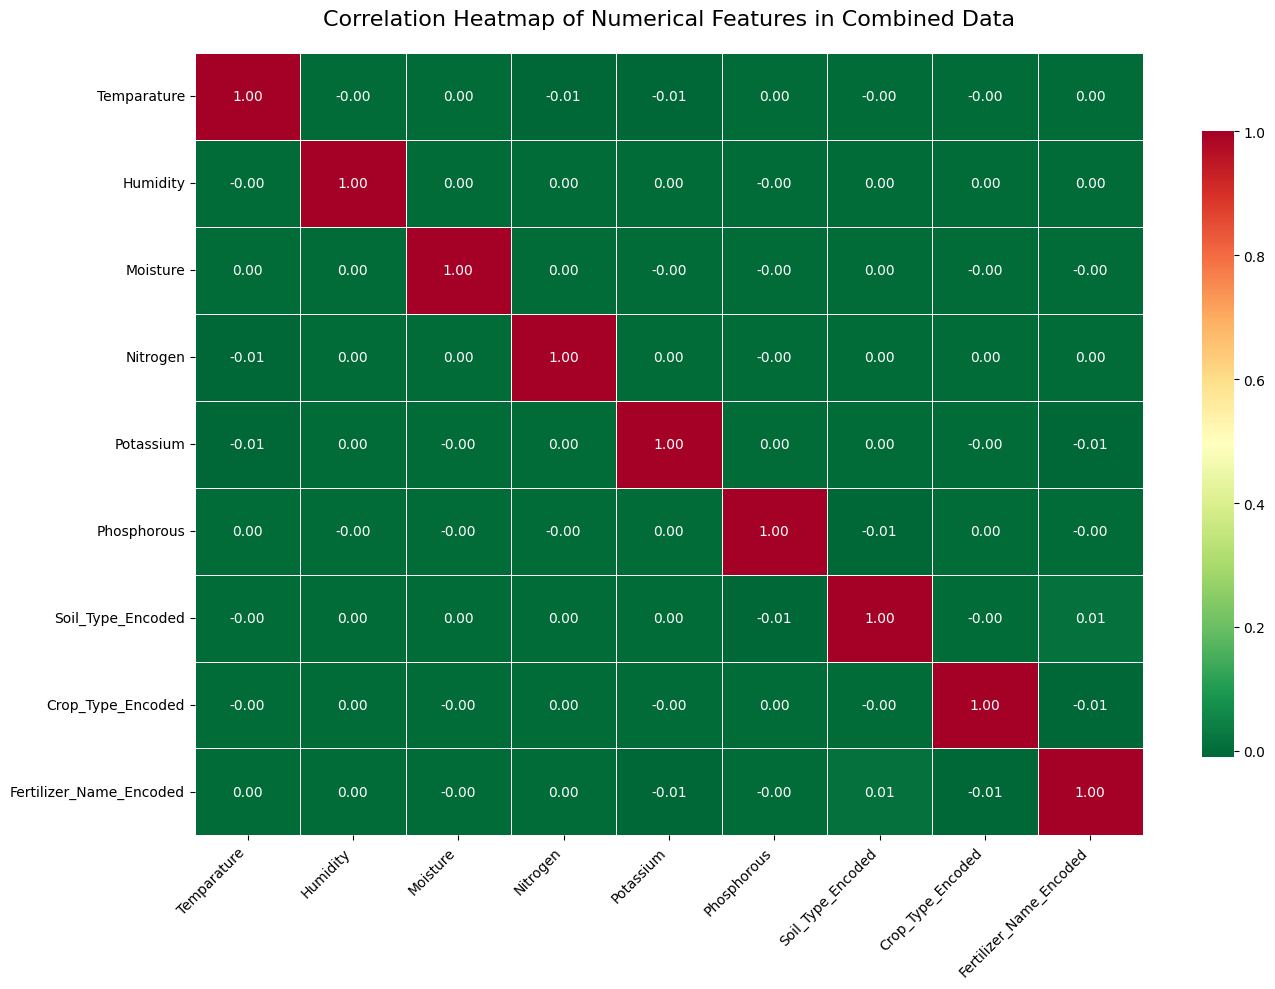

In [41]:
numerical_features = train_data.select_dtypes(include=['int64']).columns.tolist()
corr_matrix = train_data[numerical_features].corr().round(2)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdYlGn_r',
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Heatmap of Numerical Features in Combined Data', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- A correlation heatmap of numerical features, including encoded categorical variables and the target, revealed very weak correlations among features and between features and the target.  
- This indicates that features provide mostly independent information, suggesting the need for models capable of capturing complex, possibly non-linear relationships.

## Separating Features and Target

In [42]:
feature_columns = [
    'Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Phosphorous', 'Potassium',
    'Soil_Type_Encoded', 'Crop_Type_Encoded'
]
target_column = 'Fertilizer_Name_Encoded'

X = train_data[feature_columns]
y = train_data[target_column]
test_X = test_data[feature_columns]

- The input features selected for model training include environmental variables (`Temparature`, `Humidity`, `Moisture`), soil nutrients (`Nitrogen`, `Phosphorous`, `Potassium`), and encoded categorical variables (`Soil_Type_Encoded`, `Crop_Type_Encoded`).  
- The target variable is the encoded fertilizer class (`Fertilizer_Name_Encoded`).

## Defining MAP@3 Metric

In [43]:
# MAP@3 Metric
def mapk(actual, predicted, k=3):
    def apk(a, p, k):
        if len(p) > k:
            p = p[:k]
        score = 0.0
        num_hits = 0.0
        for i, pred in enumerate(p):
            if pred == a and pred not in p[:i]:
                num_hits += 1.0
                score += num_hits / (i + 1.0)
        return score
    return np.mean([apk(a, p, k) for a, p in zip(actual, predicted)])

### Evaluation Metric: Mean Average Precision at 3 (MAP\@3)

In this competition, model performance is evaluated using the **Mean Average Precision at 3** (**MAP@3**) metric. This metric rewards models that correctly predict the fertilizer type and rank it as highly as possible among the top three predictions for each test sample.

#### 🔍 What is MAP\@3?

**MAP@3** measures how well the top three predicted fertilizer names match the true fertilizer for each test instance. The score is higher if the correct fertilizer appears earlier in the list of predictions.

#### 🧮 Mathematical Definition

The general formula for Mean Average Precision at K (MAP\@K) is:

$$
\text{MAP@K} = \frac{1}{U} \sum_{u=1}^{U} \sum_{k=1}^{\min(n, K)} P(k) \times \text{rel}(k)
$$

Where:

* $U$: total number of test samples
* $n$: number of predictions per sample (up to 3)
* $P(k)$: precision at rank $k$, defined as the number of correct items in the top $k$ predictions divided by $k$
* $\text{rel}(k)$: an indicator function, 1 if the prediction at rank $k$ is correct, 0 otherwise

For this competition, **K = 3**.


#### ⚙️ How MAP\@3 Works

* For each test sample, model can predict **up to 3 fertilizer names**, ranked by confidence.
* If the correct fertilizer is **1st prediction**, the score is **1.0**.
* If it's the **2nd**, the score is **0.5**.
* If it's the **3rd**, the score is **0.333...**.
* If the correct fertilizer isn’t in the top 3, the score is **0.0**.
* The **MAP\@3 score** is the average of these individual scores over all test samples.

#### 🧪 Example

Suppose the true fertilizer is `"Urea"`:

| Predictions          | AP\@3 Score |
| -------------------- | ----------- |
| `Urea 14-35-14 DAP`  | 1.0         |
| `14-35-14 Urea DAP`  | 0.5         |
| `14-35-14 DAP Urea`  | 0.333       |
| `14-35-14 DAP 20-20` | 0.0         |

#### 🌱 Why MAP\@3?

MAP\@3 is especially useful in real-world recommendation systems like this one, where multiple options can be suggested, but ranking the correct one near the top is critical. In agriculture, suggesting the right fertilizer within the top three helps support better decision-making and crop outcomes, even if the top prediction isn't always perfect.

**References:**

* [Kaggle S5E6 Evaluation Page](https://www.kaggle.com/competitions/playground-series-s5e6/overview/evaluation)

## Model Training

**Note:** The hyperparameters used here are for demonstration purposes. You are encouraged to experiment with different hyperparameter settings to improve the prediction **mAP@3** and reduce the **log loss**.

In [44]:
params = {
    'max_depth': 7,
    'learning_rate': 0.05635134330984224,
    'subsample': 0.5605235929333594,
    'colsample_bytree': 0.5594578346445631,
    'min_child_weight': 6,
    'gamma': 0.35819323772520817,
    'reg_alpha': 0.9747714669120731,
    'reg_lambda': 0.7061465594372847,
    'objective': 'multi:softprob',
    'num_class': 7,
    'eval_metric': 'mlogloss',
    'tree_method': 'gpu_hist',
    'verbosity': 0,
    'n_estimators': 1000
}

## Cross-Validation Training with OOF & Test Predictions

In [45]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros((X.shape[0], len(np.unique(y))))
test_preds = np.zeros((test_X.shape[0], len(np.unique(y))))
oof_true = []
oof_top3_preds = []

fold_loglosses = []
fold_map3s = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold+1}")
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    model = xgb.XGBClassifier(**params, use_label_encoder=False)
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    oof_preds[valid_idx] = model.predict_proba(X_valid)
    fold_logloss = log_loss(y_valid, oof_preds[valid_idx])
    fold_loglosses.append(fold_logloss)

    top3_preds = np.argsort(oof_preds[valid_idx], axis=1)[:, -3:][:, ::-1]
    fold_map3 = mapk(y_valid.tolist(), [list(p) for p in top3_preds], k=3)
    fold_map3s.append(fold_map3)

    print(f"  Fold {fold+1} Log Loss: {fold_logloss:.5f}")
    print(f"  Fold {fold+1} MAP@3: {fold_map3:.5f}")

    oof_true.extend(y_valid)
    oof_top3_preds.extend(top3_preds)
    test_preds += model.predict_proba(test_X) / skf.n_splits

map3_score = mapk(oof_true, [list(p) for p in oof_top3_preds], k=3)
print(f"\nOverall OOF MAP@3 Score: {map3_score:.5f}")

Fold 1


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


  Fold 1 Log Loss: 2.02493
  Fold 1 MAP@3: 0.26088
Fold 2


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


  Fold 2 Log Loss: 2.02305
  Fold 2 MAP@3: 0.26212
Fold 3


...

  Fold 3 Log Loss: 2.02179
  Fold 3 MAP@3: 0.26176
Fold 4


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


  Fold 4 Log Loss: 2.02439
  Fold 4 MAP@3: 0.26183
Fold 5


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


  Fold 5 Log Loss: 2.02387
  Fold 5 MAP@3: 0.25936

Overall OOF MAP@3 Score: 0.26119


- A stratified 5-fold cross-validation approach was employed to ensure robust model evaluation and prevent overfitting.  
- For each fold, the model was trained on 80% of the data and validated on 20%, with early stopping to avoid unnecessary training epochs.  
- Out-of-fold (OOF) predictions were collected to estimate generalization performance, and test set predictions were averaged across folds for final submission.

## Fold Performance

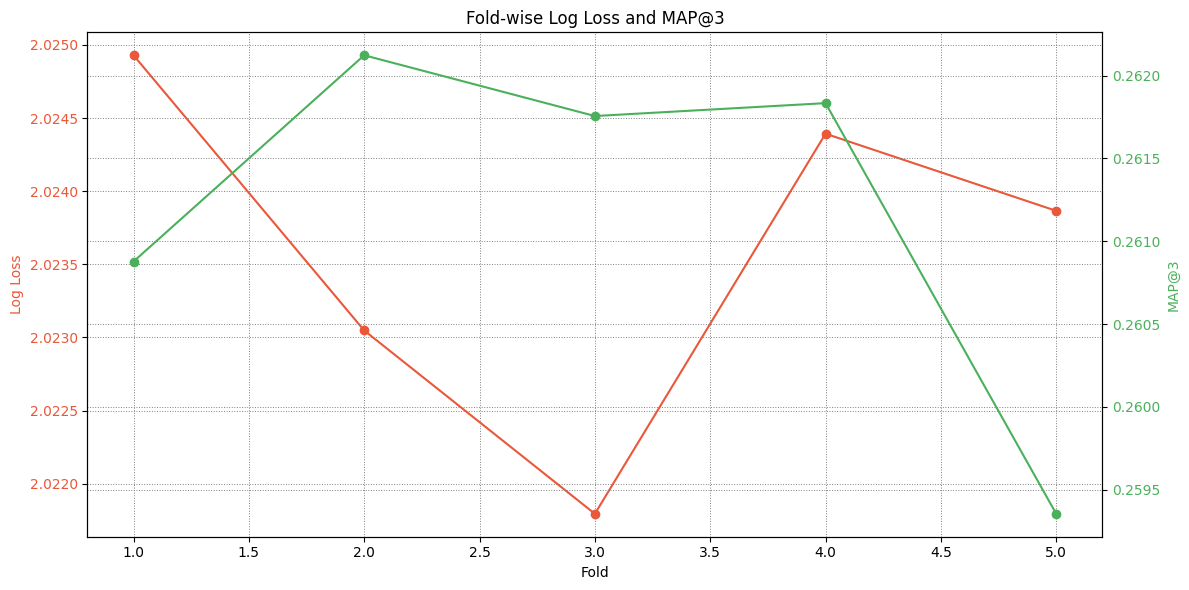

In [46]:
colors = sns.color_palette('RdYlGn', 5)
folds = list(range(1, 6))
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_title('Fold-wise Log Loss and MAP@3')
ax1.plot(folds, fold_loglosses, marker='o', color=colors[0], label='Log Loss')
ax1.set_xlabel('Fold')
ax1.set_ylabel('Log Loss', color=colors[0])
ax1.tick_params(axis='y', labelcolor=colors[0])
ax1.grid(color='gray', linestyle=':', linewidth=0.7)

ax2 = ax1.twinx()
ax2.plot(folds, fold_map3s, marker='o', color=colors[4], label='MAP@3')
ax2.set_ylabel('MAP@3', color=colors[4])
ax2.tick_params(axis='y', labelcolor=colors[4])
ax2.grid(color='gray', linestyle=':', linewidth=0.7)
plt.tight_layout()
plt.show()

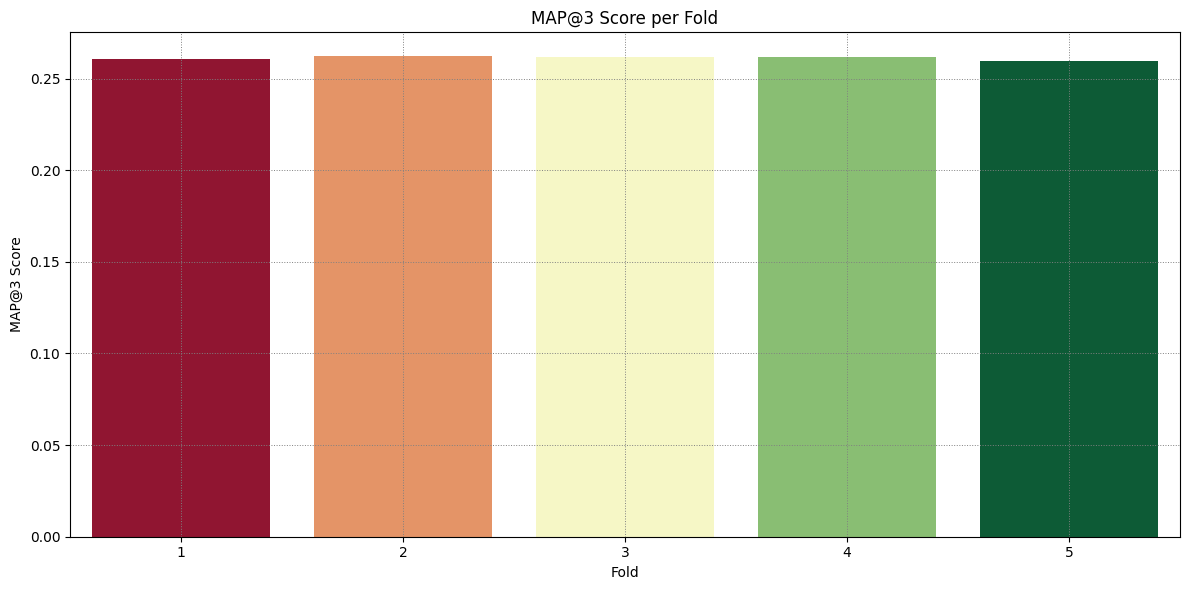

In [47]:
plt.figure(figsize=(12, 6))
sns.barplot(x=folds, y=fold_map3s, hue=folds, palette='RdYlGn', legend=False)
plt.title('MAP@3 Score per Fold')
plt.xlabel('Fold')
plt.ylabel('MAP@3 Score')
plt.grid(color='gray', linestyle=':', linewidth=0.7)
plt.tight_layout()
plt.show()

- Fold-wise log loss values were consistently around **2.02**, indicating stable model convergence.  
- MAP@3 scores per fold ranged arounf **0.26**, with an overall OOF MAP@3 of approximately **0.26119**.  
- These results demonstrate consistent model performance and reliable top-3 fertilizer prediction accuracy.

## Feature Importance

Feature Importances:
             Feature  Importance
4        Phosphorous    0.129698
3           Nitrogen    0.128696
2           Moisture    0.127955
1           Humidity    0.125813
5          Potassium    0.125221
0        Temparature    0.122922
7  Crop_Type_Encoded    0.121357
6  Soil_Type_Encoded    0.118338


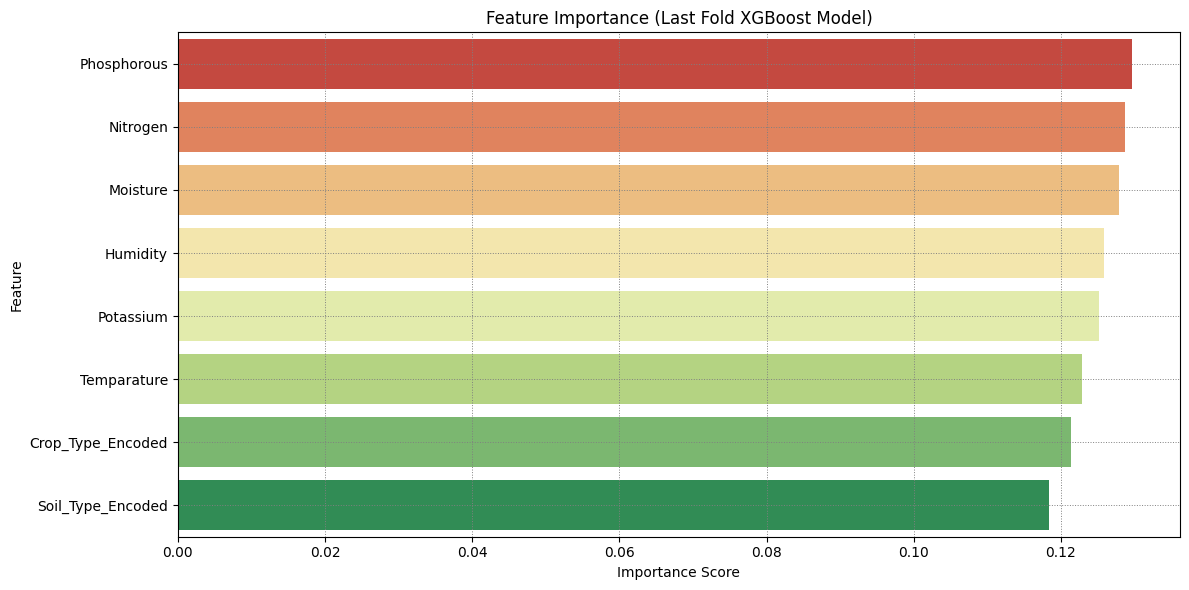

In [48]:
feature_importance = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df, 
    hue='Feature',
    palette='RdYlGn',
    legend=False
)
plt.title('Feature Importance (Last Fold XGBoost Model)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(color='gray', linestyle=':', linewidth=0.7)
plt.tight_layout()
plt.show()

#### Feature Importance Insights from XGBoost Model

**Overview of Feature Importance**

- The feature importance analysis from the final fold of the trained XGBoost model reveals the relative contribution of each feature in predicting the fertilizer class.  
- Understanding feature importance helps interpret the model’s decision-making process and identifies the most influential factors affecting fertilizer recommendations.

**Key Findings**

- **Phosphorous** emerges as the most important feature, contributing approximately 12.9% to the model’s predictive power. This aligns with its critical role in plant development and nutrient uptake.  
- **Nitrogen** and **Moisture** follow closely, with importance scores around 12.8% and 12.7%, respectively, highlighting their vital influence on fertilizer needs and soil-crop interactions.  
- The encoded **Humidity** feature ranks fourth, indicating that crop-specific nutrient requirements significantly affect fertilizer choice.  
- **Potassium**, **Temperature**, and **Crop Type** also have meaningful contributions, reflecting the combined effect of soil nutrients and environmental conditions.  
- The encoded **Soil Type** feature, while slightly less influential, still plays a notable role, capturing soil-specific characteristics that impact fertilizer effectiveness.

**Agronomic and Modeling Implications**

- The prominence of soil nutrients (Phosphorous, Nitrogen, Potassium) as top predictors confirms their fundamental importance in fertilizer recommendation systems, consistent with agronomic knowledge.  
- Environmental factors like moisture, humidity, and temperature also influence fertilizer effectiveness by affecting nutrient availability and crop stress levels.  
- Crop type’s high importance underscores the need for crop-specific fertilization strategies to optimize yield and resource use.  
- Soil type, though less dominant, remains essential for capturing soil heterogeneity and guiding localized fertilizer application.

In [49]:
fertilizer_decoder = dict(zip(target_le.transform(target_le.classes_), target_le.classes_))
test_top3_preds = np.argsort(test_preds, axis=1)[:, -3:][:, ::-1]

final_labels = []
for row in test_top3_preds:
    labels = [fertilizer_decoder[i] for i in row]
    final_labels.append(' '.join(labels))

first = []
second = []
third = []

for label in final_labels:
    parts = label.split()  
    if len(parts) == 3:
        first.append(parts[0])
        second.append(parts[1])
        third.append(parts[2])
    else:
        print(f"Skipping malformed label: {label}")

test_data['First_Fertilizer']=first
test_data['Second_Fertilizer']=second
test_data['Third_Fertilizer']=third

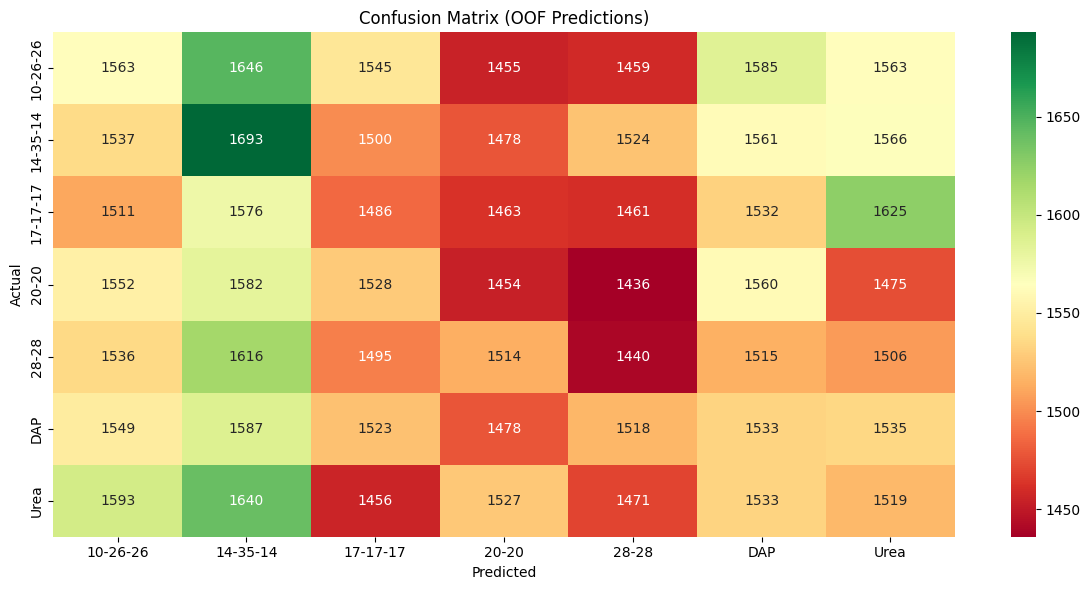

In [50]:
oof_pred_top1 = np.argmax(oof_preds, axis=1)
cm = pd.crosstab(pd.Series(oof_true), pd.Series(oof_pred_top1))
cm.index = [fertilizer_decoder[i] for i in cm.index]
cm.columns = [fertilizer_decoder[i] for i in cm.columns]

plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn')
plt.title('Confusion Matrix (OOF Predictions)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Confusion Matrix Analysis of Out-of-Fold Predictions

- The confusion matrix constructed from out-of-fold (OOF) predictions provides a detailed view of the model’s classification performance across fertilizer classes.  
- The matrix rows represent the actual fertilizer classes, while columns represent the predicted classes, allowing identification of common misclassifications.  
- Diagonal entries indicate correct predictions, with values ranging from approximately 1400 to 1700 samples per class, reflecting the model’s strengths. 

Top-1 Fertilizer Prediction Counts:
  Fertilizer  Count
0   14-35-14   3755
1       Urea   3629
2   17-17-17   3616
3        DAP   3591
4   10-26-26   3540
5      28-28   3441
6      20-20   3428


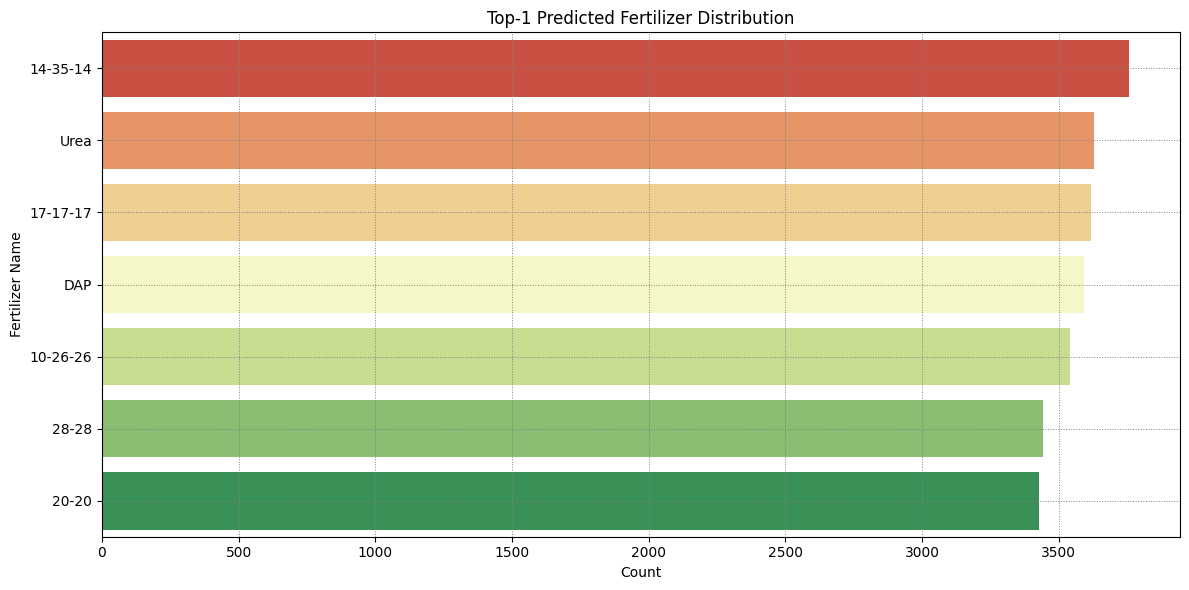

In [51]:
top1_preds = np.argmax(test_preds, axis=1)

top1_labels = [fertilizer_decoder[i] for i in top1_preds]

top1_counts = pd.Series(top1_labels).value_counts().reset_index()
top1_counts.columns = ['Fertilizer', 'Count']

print("Top-1 Fertilizer Prediction Counts:")
print(top1_counts)

plt.figure(figsize=(12, 6))
sns.barplot(data=top1_counts, x='Count', y='Fertilizer', hue='Fertilizer', palette='RdYlGn', legend=False)
plt.title('Top-1 Predicted Fertilizer Distribution')
plt.xlabel('Count')
plt.ylabel('Fertilizer Name')
plt.grid(color='gray', linestyle=':', linewidth=0.7)
plt.tight_layout()
plt.show()

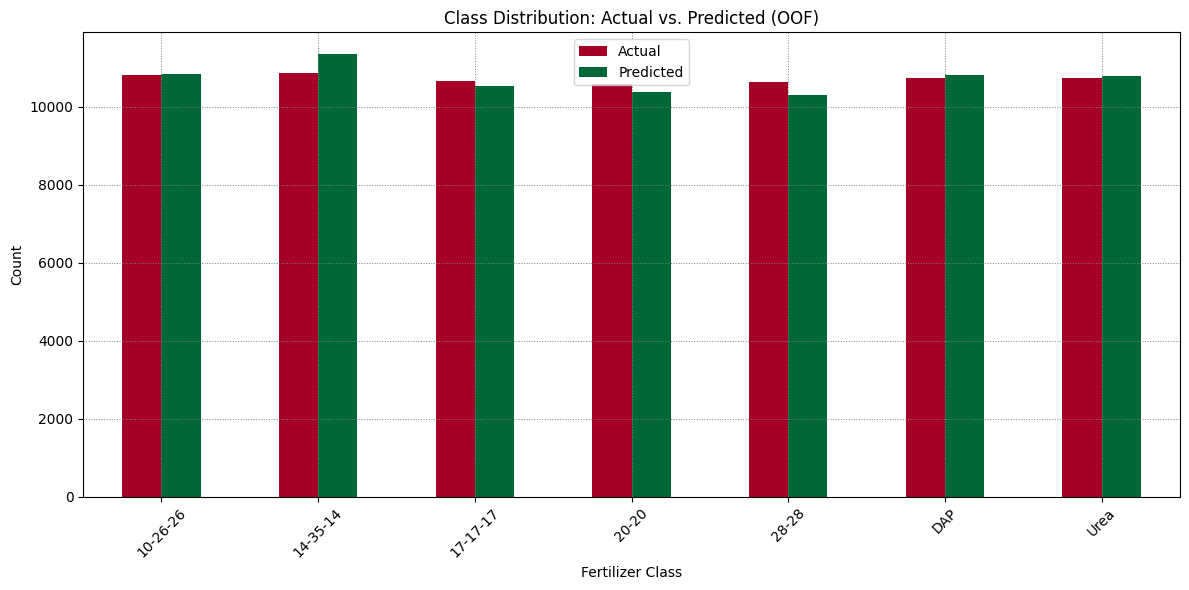

In [52]:
oof_pred_top1_names = [fertilizer_decoder[i] for i in oof_pred_top1]
oof_true_names = [fertilizer_decoder[i] for i in oof_true]

actual_dist = pd.Series(oof_true_names).value_counts().sort_index()
predicted_dist = pd.Series(oof_pred_top1_names).value_counts().sort_index()

dist_df = pd.DataFrame({
    'Actual': actual_dist,
    'Predicted': predicted_dist
}).fillna(0)

dist_df.plot(kind='bar', figsize=(12, 6), colormap='RdYlGn')
plt.title('Class Distribution: Actual vs. Predicted (OOF)')
plt.xlabel('Fertilizer Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(color='gray', linestyle=':', linewidth=0.7)
plt.tight_layout()
plt.show()

### Analysis of Model Predictions and Class Distribution

#### Top-1 Fertilizer Predictions Distribution

* The model's predictions on the test set are balanced, with no single fertilizer class dominating the recommendations.
* The prediction counts are close to one another. For example, `14-35-14` is the most predicted class at **3,755**, while the least predicted, `20-20`, has a count of **3,428**.
* The top predicted classes include `14-35-14` (3,755), `Urea` (3,629), and `17-17-17` (3,616).
* This distribution indicates the model does not exhibit a strong predictive bias towards any particular fertilizer in this test set.

#### Comparison of Actual vs. Predicted Class Distributions (OOF)

* The chart comparing out-of-fold (OOF) predictions to actual labels shows the model's level of calibration.
* The model's predicted class distribution (green bars) closely follows the actual class distribution (red bars). This demonstrates an alignment between the model's predictions and the true frequency of each class in the dataset.
* For most classes, such as `10-26-26`, `DAP`, and `Urea`, the predicted and actual counts are nearly identical.
* The discrepancies that exist are small, consisting of a slight over-prediction for `14-35-14` and slight under-predictions for a few other classes.

In [53]:
test_data.head()

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous,Soil_Type_Encoded,Crop_Type_Encoded,First_Fertilizer,Second_Fertilizer,Third_Fertilizer
75721,26,64,31,29,13,5,2,0,10-26-26,14-35-14,20-20
80184,30,67,62,17,16,33,1,5,DAP,28-28,Urea
19864,31,62,58,30,2,27,4,7,Urea,17-17-17,14-35-14
76699,25,51,30,31,4,10,3,4,20-20,10-26-26,14-35-14
92991,30,52,44,32,19,27,4,7,20-20,14-35-14,Urea


The model's top-3 fertilizer predictions for each sample are stored in the DataFrame test_data, in the columns 'First_Fertilizer', 'Second_Fertilizer', and 'Third_Fertilizer'. The DataFrame is printed above for reference.